# STEP 1: Problem Statement-
Flight ticket prices can be something hard to guess, today we might see a price, check out the price of the same flight tomorrow, it will be a different story. We might have often heard travelers saying that flight ticket prices are so unpredictable. That’s why we will try to use machine learning to solve this problem. This can help airlines by predicting what prices they can maintain.

- Task 1:-Prepare a complete data analysis report on the given data.

- Task 2:-Create a predictive model which will help the customers to predict future flight prices and plan their journey accordingly.


# STEP 2: Import Basic Libraries-

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

# STEP 3: Load Dataset-

In [2]:
data = pd.read_excel("Flight_Fare.xlsx")
data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


# STEP 4: Domain Analysis-

### ✈️ Domain Analysis — Flight Fare Prediction

- The airline industry uses **dynamic pricing**, where fares vary based on demand, route, duration, season, and airline type.  
- The main goal is to **predict flight ticket prices** using available flight details like airline, total stops, journey date, duration, and route.  
- **Key factors influencing price:**
  - Number of stops — more stops usually mean lower fares.
  - Duration — longer flights often cost more.
  - Airline and route — premium airlines and longer routes charge higher fares.
  - Journey time (morning/evening) and travel month — capture demand patterns.  
- The project helps **airlines** optimize pricing strategies and **travelers** find cheaper flight options.




# STEP 5: Basic Checks-

In [3]:
# head
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
# tail
data.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [5]:
# shape
data.shape

(10683, 11)

In [6]:
# print all columns
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [7]:
# dtypes
data.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [8]:
# info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [9]:
# describe
data.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [10]:
data.describe(include='object').T

,count,unique,top,freq
Airline,10683,12,Jet Airways,3849
Date_of_Journey,10683,44,18/05/2019,504
Source,10683,5,Delhi,4537
Destination,10683,6,Cochin,4537
Route,10682,128,DEL → BOM → COK,2376
Dep_Time,10683,222,18:55,233
Arrival_Time,10683,1343,19:00,423
Duration,10683,368,2h 50m,550
Total_Stops,10682,5,1 stop,5625
Additional_Info,10683,10,No info,8345


#### Insights:-

**Price Insights:**
- **Mean price**: ₹9,087 with high variability (std = ₹4,611)
- **Right-skewed distribution**: Mean > Median (₹8,372), indicating some high-price outliers

**Categorical Insights:**
- **Market dominance**: Jet Airways most frequent (3,849 flights)
- **Key route**: Delhi → Bombay → Cochin most common (2,376 flights)
- **Busiest airport**: Delhi is most frequent source (4,537 flights)
- **Missing data**: Route & Total_Stops have 1 missing value each
- **Stops**: Majority of flights have 1 stop (5,625 flights)
- **Limited info**: 78% of flights have "No info" in Additional_Info

**Feature Engineering Opportunities:**
- **Date_of_Journey**: Should be parsed into day/month/year/day_of_week
- **Time features**: Extract hour from Dep_Time (18:55 most common)
- **Duration**: Convert from string "2h 50m" to minutes for modeling
- **Route analysis**: Could extract stop cities from route string
- **Additional_Info**: Most values are "No info" - consider dropping or grouping rare categories

In [11]:
# check for missing values
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

# STEP 6: Feature Engineering-

In [12]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [13]:
data.shape

(10683, 11)

In [14]:
# Handling Missing values:
data = data.dropna()

In [15]:
# check for duplicate values
data.duplicated().sum()

220

In [16]:
data = data.drop_duplicates(keep='first')
data.shape

(10462, 11)

### 1) Date & Time Features (from Date_of_Journey):-

In [17]:
data['Journey_Day'] = pd.to_datetime(data['Date_of_Journey']).dt.day
data['Journey_Month'] = pd.to_datetime(data['Date_of_Journey']).dt.month
data['Journey_Year'] = pd.to_datetime(data['Date_of_Journey']).dt.year
data['Journey_Weekday'] = pd.to_datetime(data['Date_of_Journey']).dt.dayofweek

data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Year,Journey_Weekday
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,6
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,2
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019,6
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019,6
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019,4


### 2) Time-Based Features (from Dep_Time & Arrival_Time):-

In [18]:
def get_period(hour):
    if 0 <= hour < 6:
        return 'Night'
    elif 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

In [19]:
# Departure Time
data['Dep_Hour'] = pd.to_datetime(data['Dep_Time']).dt.hour
data['Dep_Minute'] = pd.to_datetime(data['Dep_Time']).dt.minute
data['Dep_Period'] = data['Dep_Hour'].apply(get_period)

# Arrival Time
data['Arrival_Hour'] = pd.to_datetime(data['Arrival_Time'].str.split(' ').str[0]).dt.hour
data['Arrival_Minute'] = pd.to_datetime(data['Arrival_Time'].str.split(' ').str[0]).dt.minute
data['Arrival_Period'] = data['Arrival_Hour'].apply(get_period)

data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,...,Journey_Day,Journey_Month,Journey_Year,Journey_Weekday,Dep_Hour,Dep_Minute,Dep_Period,Arrival_Hour,Arrival_Minute,Arrival_Period
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,...,24,3,2019,6,22,20,Evening,1,10,Night
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,...,1,5,2019,2,5,50,Night,13,15,Afternoon
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,...,9,6,2019,6,9,25,Morning,4,25,Night
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,...,12,5,2019,6,18,5,Evening,23,30,Evening
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,...,1,3,2019,4,16,50,Afternoon,21,35,Evening


### 3) Duration Feature:-

In [20]:
def duration_to_minutes(duration):
    if 'h' in duration and 'm' in duration:
        hours = int(duration.split('h')[0])
        minutes = int(duration.split('h')[1].split('m')[0])
        return hours*60 + minutes
    elif 'h' in duration:
        return int(duration.split('h')[0])*60
    else:
        return int(duration.split('m')[0])

data['Duration_Minutes'] = data['Duration'].apply(duration_to_minutes)
data['Duration_Hours'] = data['Duration_Minutes'] / 60

data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,...,Journey_Year,Journey_Weekday,Dep_Hour,Dep_Minute,Dep_Period,Arrival_Hour,Arrival_Minute,Arrival_Period,Duration_Minutes,Duration_Hours
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,...,2019,6,22,20,Evening,1,10,Night,170,2.833333
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,...,2019,2,5,50,Night,13,15,Afternoon,445,7.416667
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,...,2019,6,9,25,Morning,4,25,Night,1140,19.000000
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,...,2019,6,18,5,Evening,23,30,Evening,325,5.416667
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,...,2019,4,16,50,Afternoon,21,35,Evening,285,4.750000


### 4) Route & Stops Features:-

In [21]:
data["Total_Stops"].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [22]:
# From Total_Stops
data['Stops_Numeric'] = data['Total_Stops'].map({'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4})

# From Route column
data['Route_Cities_Count'] = data['Route'].apply(lambda x: len(x.split('→')))
data['Is_Direct'] = (data['Route_Cities_Count'] == 2).astype(int)

data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,...,Dep_Minute,Dep_Period,Arrival_Hour,Arrival_Minute,Arrival_Period,Duration_Minutes,Duration_Hours,Stops_Numeric,Route_Cities_Count,Is_Direct
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,...,20,Evening,1,10,Night,170,2.833333,0,2,1
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,...,50,Night,13,15,Afternoon,445,7.416667,2,4,0
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,...,25,Morning,4,25,Night,1140,19.000000,2,4,0
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,...,5,Evening,23,30,Evening,325,5.416667,1,3,0
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,...,50,Afternoon,21,35,Evening,285,4.750000,1,3,0


### 5) Additional Info Feature:-

In [23]:
data["Additional_Info"].unique()

array(['No info', 'In-flight meal not included',
       'No check-in baggage included', '1 Short layover', 'No Info',
       '1 Long layover', 'Change airports', 'Business class',
       'Red-eye flight', '2 Long layover'], dtype=object)

In [24]:
data['Has_Additional_Info'] = ((data['Additional_Info'] != 'No info') &
                               (data['Additional_Info'] != 'No Info')).astype(int)

data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,...,Dep_Period,Arrival_Hour,Arrival_Minute,Arrival_Period,Duration_Minutes,Duration_Hours,Stops_Numeric,Route_Cities_Count,Is_Direct,Has_Additional_Info
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,...,Evening,1,10,Night,170,2.833333,0,2,1,0
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,...,Night,13,15,Afternoon,445,7.416667,2,4,0,0
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,...,Morning,4,25,Night,1140,19.000000,2,4,0,0
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,...,Evening,23,30,Evening,325,5.416667,1,3,0,0
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,...,Afternoon,21,35,Evening,285,4.750000,1,3,0,0


In [25]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_Day', 'Journey_Month',
       'Journey_Year', 'Journey_Weekday', 'Dep_Hour', 'Dep_Minute',
       'Dep_Period', 'Arrival_Hour', 'Arrival_Minute', 'Arrival_Period',
       'Duration_Minutes', 'Duration_Hours', 'Stops_Numeric',
       'Route_Cities_Count', 'Is_Direct', 'Has_Additional_Info'],
      dtype='object')

In [26]:
# Drop irrelavant columns
# Journey_Year is a constant feature so drop it
data.drop(['Date_of_Journey', 'Route', 'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops', 'Additional_Info', 'Journey_Year'], inplace=True, axis=1)
data.head()

,Airline,Source,Destination,Price,Journey_Day,Journey_Month,Journey_Weekday,Dep_Hour,Dep_Minute,Dep_Period,Arrival_Hour,Arrival_Minute,Arrival_Period,Duration_Minutes,Duration_Hours,Stops_Numeric,Route_Cities_Count,Is_Direct,Has_Additional_Info
0,IndiGo,Banglore,New Delhi,3897,24,3,6,22,20,Evening,1,10,Night,170,2.833333,0,2,1,0
1,Air India,Kolkata,Banglore,7662,1,5,2,5,50,Night,13,15,Afternoon,445,7.416667,2,4,0,0
2,Jet Airways,Delhi,Cochin,13882,9,6,6,9,25,Morning,4,25,Night,1140,19.000000,2,4,0,0
3,IndiGo,Kolkata,Banglore,6218,12,5,6,18,5,Evening,23,30,Evening,325,5.416667,1,3,0,0
4,IndiGo,Banglore,New Delhi,13302,1,3,4,16,50,Afternoon,21,35,Evening,285,4.750000,1,3,0,0


In [27]:
data.columns

Index(['Airline', 'Source', 'Destination', 'Price', 'Journey_Day',
       'Journey_Month', 'Journey_Weekday', 'Dep_Hour', 'Dep_Minute',
       'Dep_Period', 'Arrival_Hour', 'Arrival_Minute', 'Arrival_Period',
       'Duration_Minutes', 'Duration_Hours', 'Stops_Numeric',
       'Route_Cities_Count', 'Is_Direct', 'Has_Additional_Info'],
      dtype='object')

# STEP 7: Exploratory Data Analysis-
 ### a) Univariate Analysis


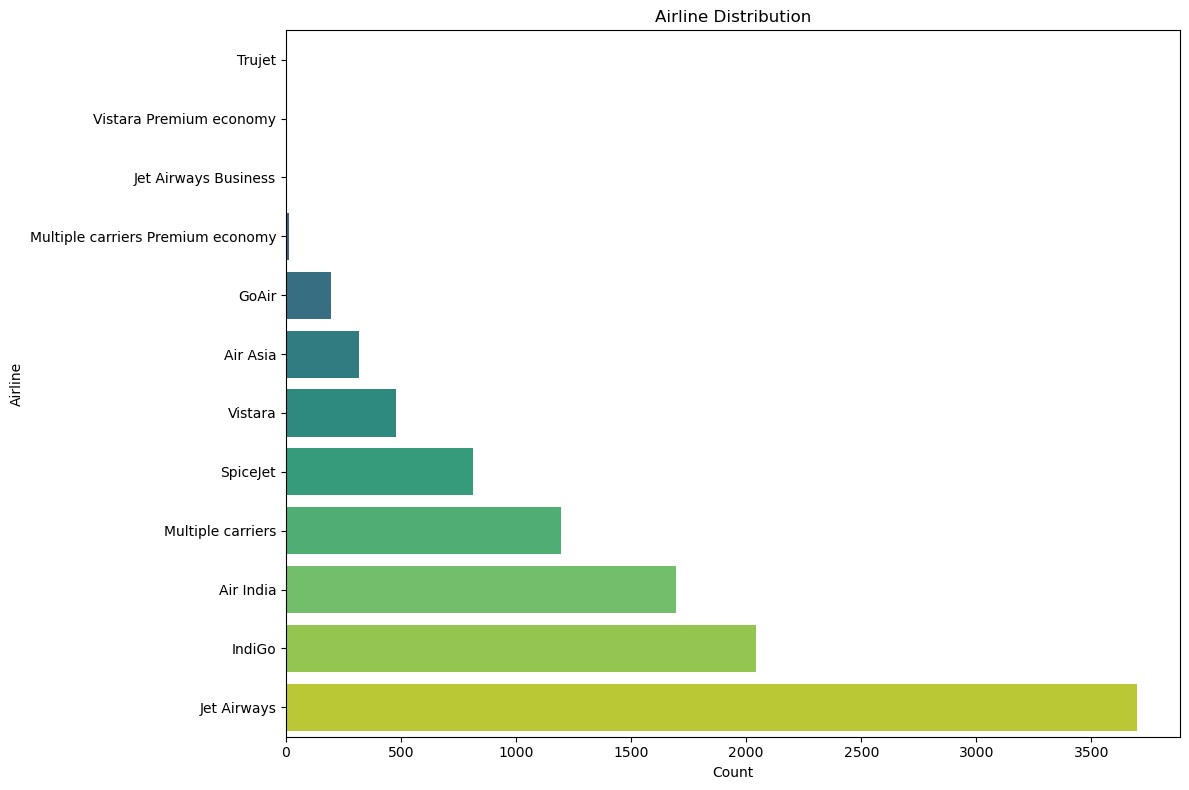

In [28]:
plt.figure(figsize=(12,8))
airline_counts = data['Airline'].value_counts().sort_values(ascending=True)
sns.barplot(x=airline_counts.values, y=airline_counts.index, palette='viridis')
plt.title('Airline Distribution')
plt.xlabel('Count')
plt.ylabel('Airline')
plt.tight_layout()
plt.show()

#### Insights:-
* **Market Dominance:** Jet Airways is the clear market leader with the highest flight count, followed by IndiGo and Air India.
* **Service Tiers:** Basic economy carriers (Jet Airways, IndiGo, Air India, SpiceJet) dominate the volume, suggesting this dataset primarily consists of standard/affordable flights.
* **Premium Options:** Premium services (Vistara Premium economy, Jet Airways Business) exist but have significantly lower counts, indicating they represent niche or less common offerings.
* **Carrier Types:**
    * **Low-Cost Carriers (LCCs):** IndiGo, SpiceJet, GoAir, and Air Asia form a substantial mid-tier volume block.
    * **Full-Service Carriers (FSCs):** Air India and Vistara (standard) are present but have fewer flights than the top LCCs.

In [29]:
feature_set_1 = ['Source', 'Destination', 'Journey_Weekday',
                 'Dep_Period', 'Arrival_Period', 'Is_Direct', 'Has_Additional_Info']

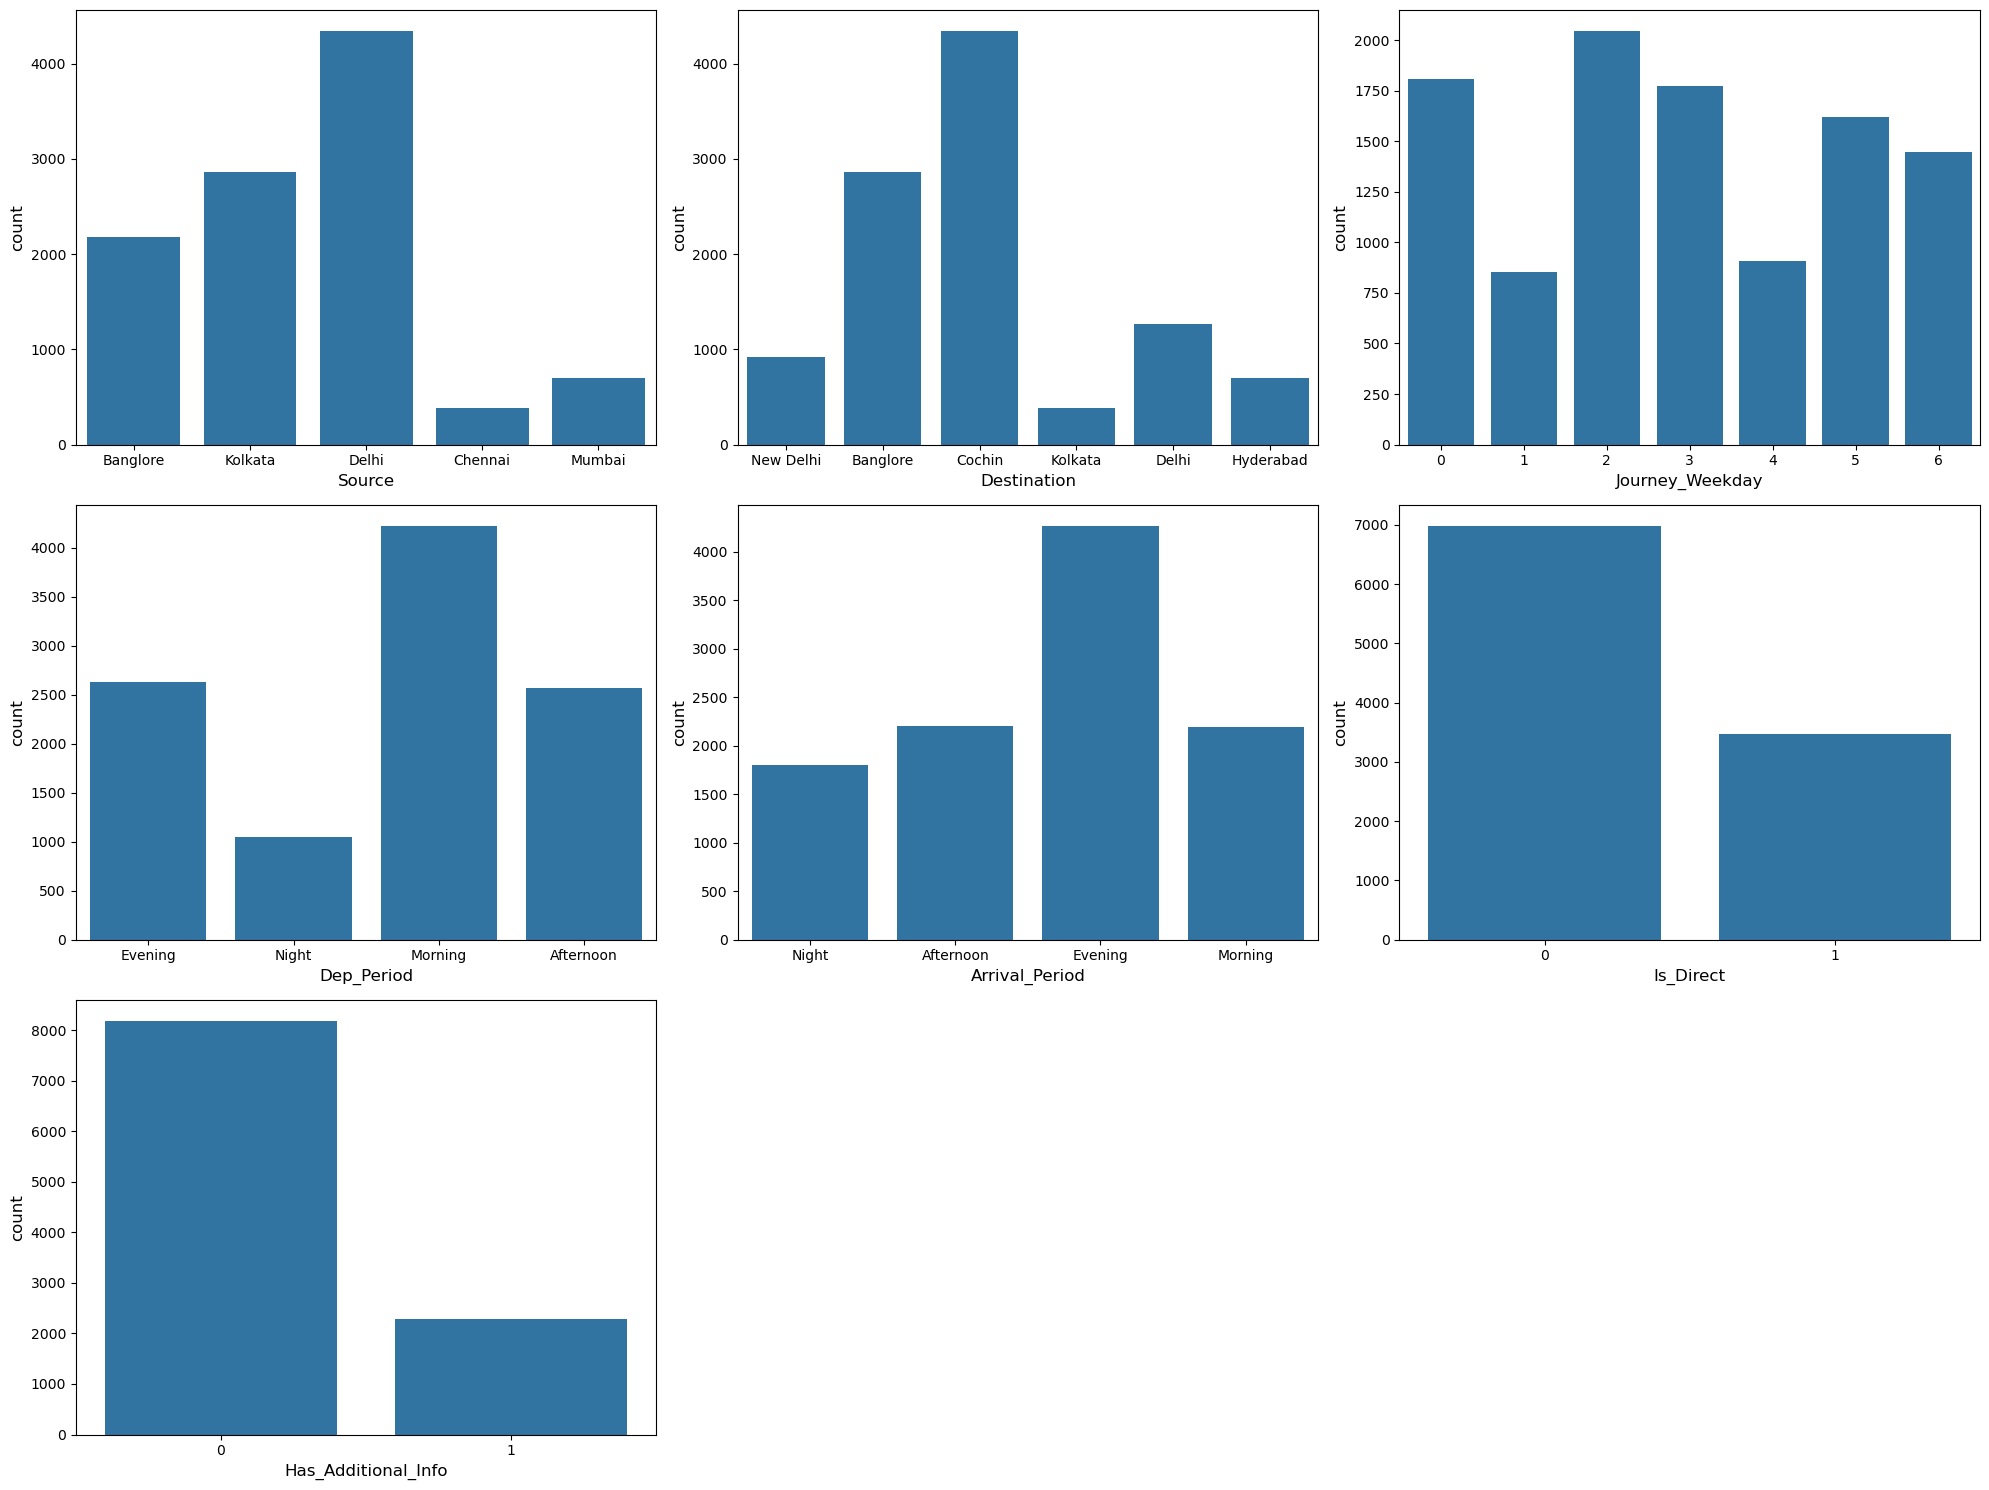

In [30]:
plt.figure(figsize=(20,15), facecolor='white')
plotnumber = 1

for column in feature_set_1:
    if plotnumber <= 7:
        ax = plt.subplot(3,3, plotnumber)
        sns.countplot(x=data[column])

        plt.xlabel(column, fontsize=12)
        plt.ylabel("count", fontsize=12)

    plotnumber += 1

plt.tight_layout()
plt.show()

#### Insights:-
* **Travel Hubs:** Delhi is by far the **busiest source airport**, while Cochin is the **most common destination**.
* **Popular Routes:** Delhi → Cochin appears to be a major travel corridor.
* **Day Distribution:** Flights are **evenly distributed** across all weekdays (0–6), indicating no strong weekend/weekday bias.
* **Timing Preferences:**
    * **Evening** is the most popular departure time.
    * **Morning** is the most popular arrival time.
    * This suggests a preference for **overnight or morning arrival** flights.
* **Additional Information:** Most entries have **no additional booking info**.



In [31]:
feature_set_2 = ['Price', 'Duration_Minutes', 'Duration_Hours',
                 'Dep_Hour', 'Arrival_Hour', 'Route_Cities_Count']

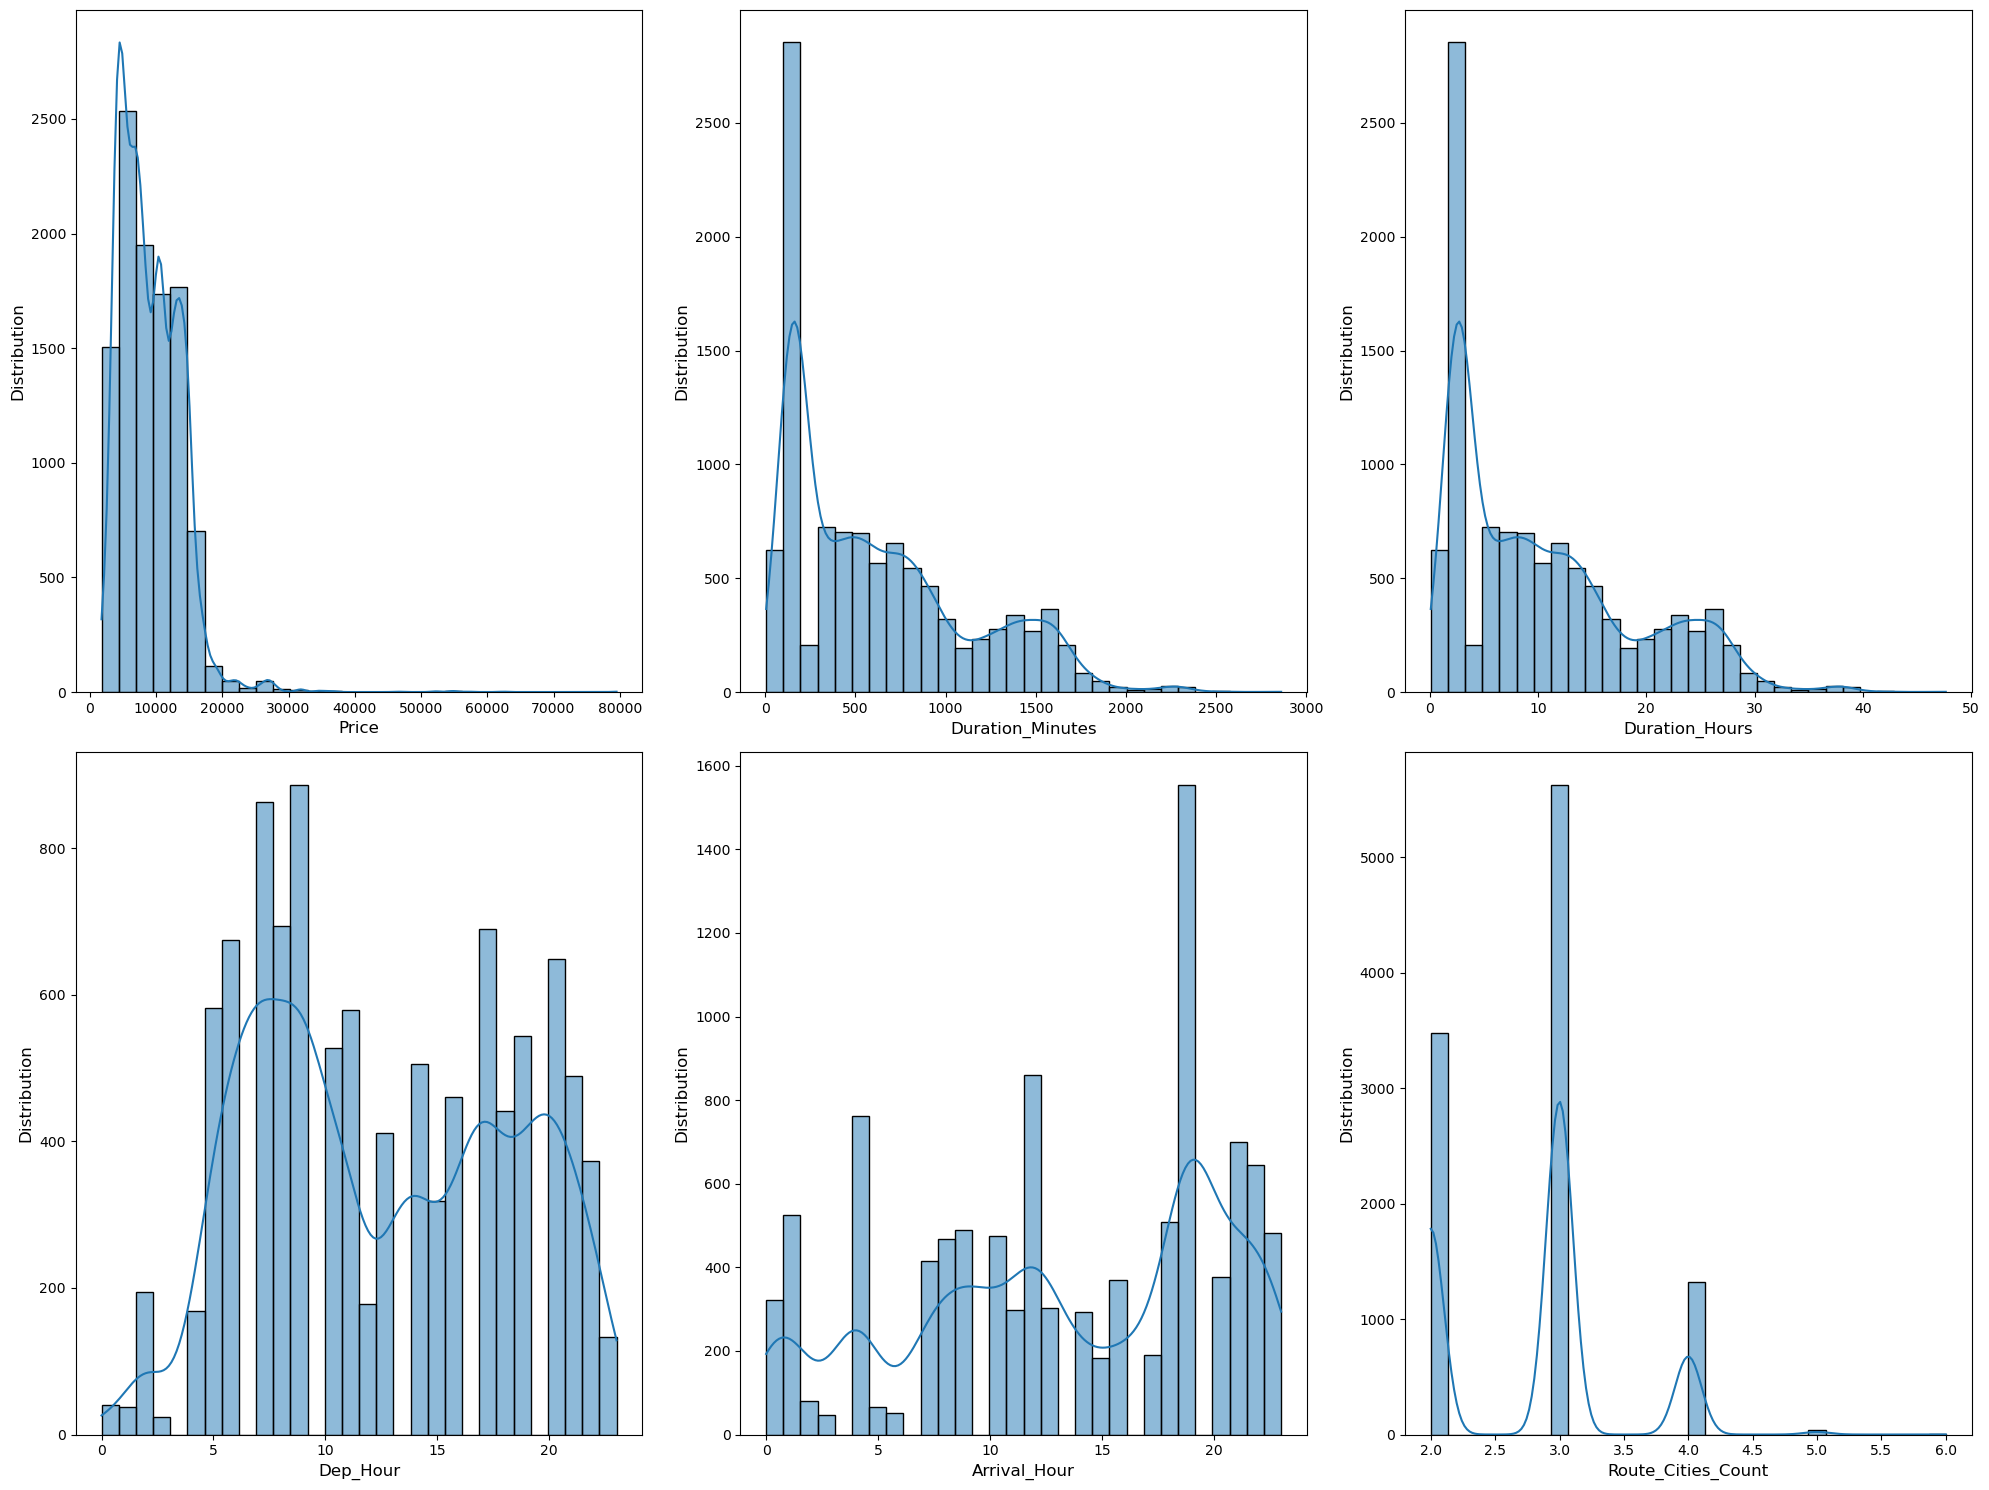

In [32]:
plt.figure(figsize=(20,15), facecolor='white')
plotnumber = 1

for column in feature_set_2:
    if plotnumber <= 6:
        ax = plt.subplot(2,3, plotnumber)
        sns.histplot(x=data[column], kde=True, bins=30)

        plt.xlabel(column, fontsize=12)
        plt.ylabel("Distribution", fontsize=12)

    plotnumber += 1

plt.tight_layout()
plt.show()

#### Insights:-

**Price Distribution:**

* Highly **right-skewed** (positive skew).
* Most ticket prices fall in the **₹2,000–₹15,000** range.
* A few extreme high prices create a **long tail**, indicating outliers.

**Duration (Minutes):**

* Clearly **right-skewed**.
* Majority of flights last **under 500 minutes (~8 hours)**.
* A long tail shows some **very long multi-stop flights**.

**Duration (Hours):**

* Same pattern as minutes → **positively skewed**.
* Most flights are **1–8 hours** long, with rare cases reaching **20+ hours**.


**Departure Hour:**

* Distribution is **bimodal**, not skewed.
* Peak departures around **morning (6–10 AM)** and **evening (5–9 PM)**.
* Very few flights at night/early morning.

**Arrival Hour:**

* Also **multimodal**; no strong skewness.
* Arrivals cluster around **morning**, **afternoon**, and **late evening**.
* Very few arrivals between **midnight–5 AM**.


**Route Cities Count:**

* Strongly **right-skewed**, with spike at **2–3 cities** (direct or 1-stop routes).
* 4+ city routes are very rare → appear as long-tail cases.
* Indicates majority of flights are **non-stop or single-stop**.


### b) Bivariate Analysis

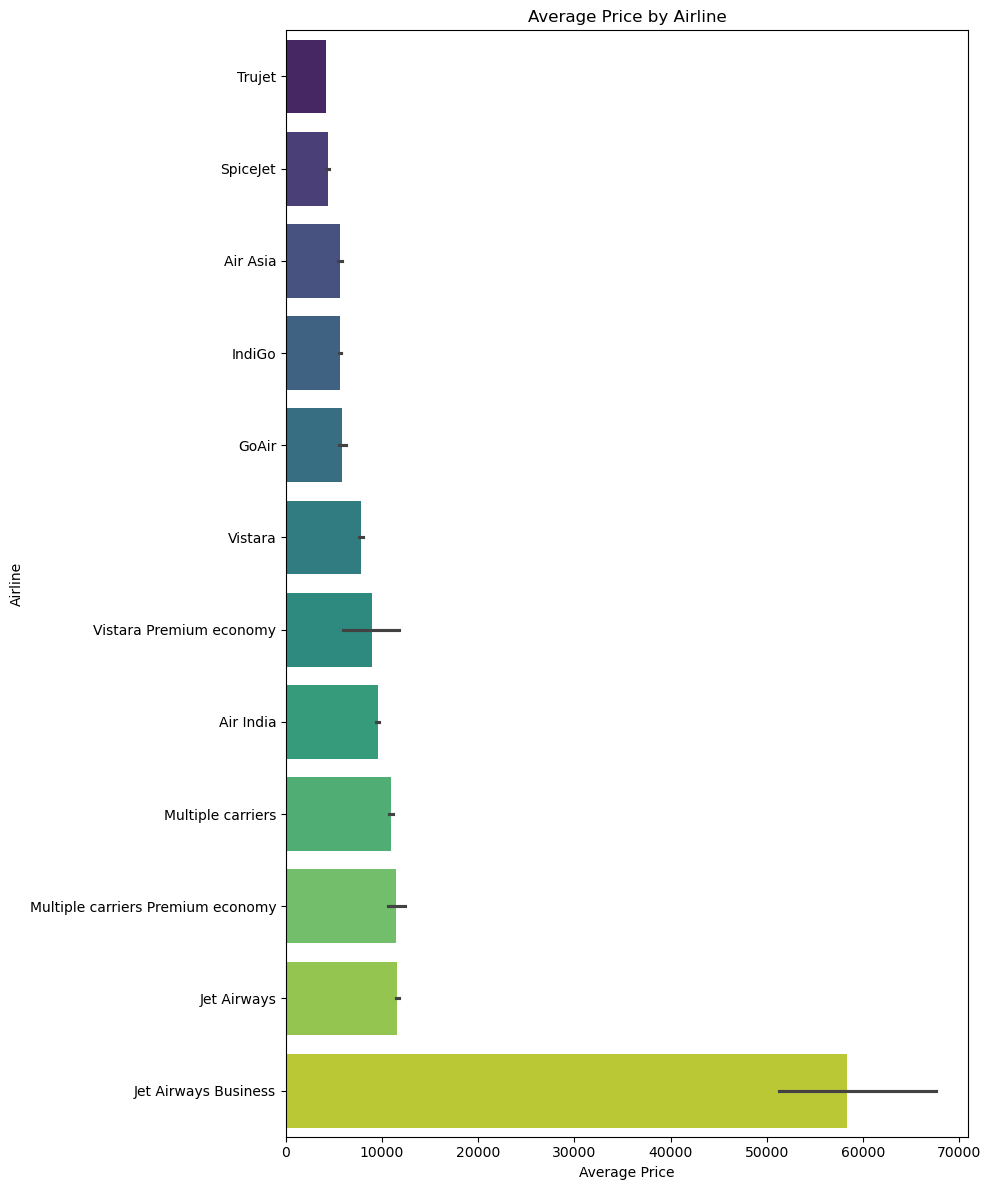

In [33]:
plt.figure(figsize=(10,12))
sns.barplot(x='Price', y='Airline', data=data, palette='viridis', estimator='mean',
            order=data.groupby('Airline')['Price'].mean().sort_values().index)
plt.title('Average Price by Airline')
plt.xlabel('Average Price')
plt.ylabel('Airline')
plt.tight_layout()
plt.show()

#### Insights:-

- **Clear price hierarchy**: Jet Airways Business (₹68K+) is premium; Trujet (₹6K) is most economical
- **Three tiers visible**:
  - **Budget**: Trujet, SpiceJet, Air Asia, IndiGo, GoAir (<₹10K)
  - **Mid-range**: Vistara, Vistara Premium, Air India, Multiple carriers (₹15-30K)
  - **Premium**: Jet Airways Business (₹68K)
- **Premium economy markup**: Vistara Premium is ~₹10K higher than regular Vistara
- **Market leader**: Jet Airways (regular) positions as mid-high range despite being most frequent airline
- **Business class premium**: Jet Airways Business is 3× price of regular Jet Airways

In [34]:
feature_set_3 = ['Source', 'Destination', 'Dep_Period', 'Arrival_Period']

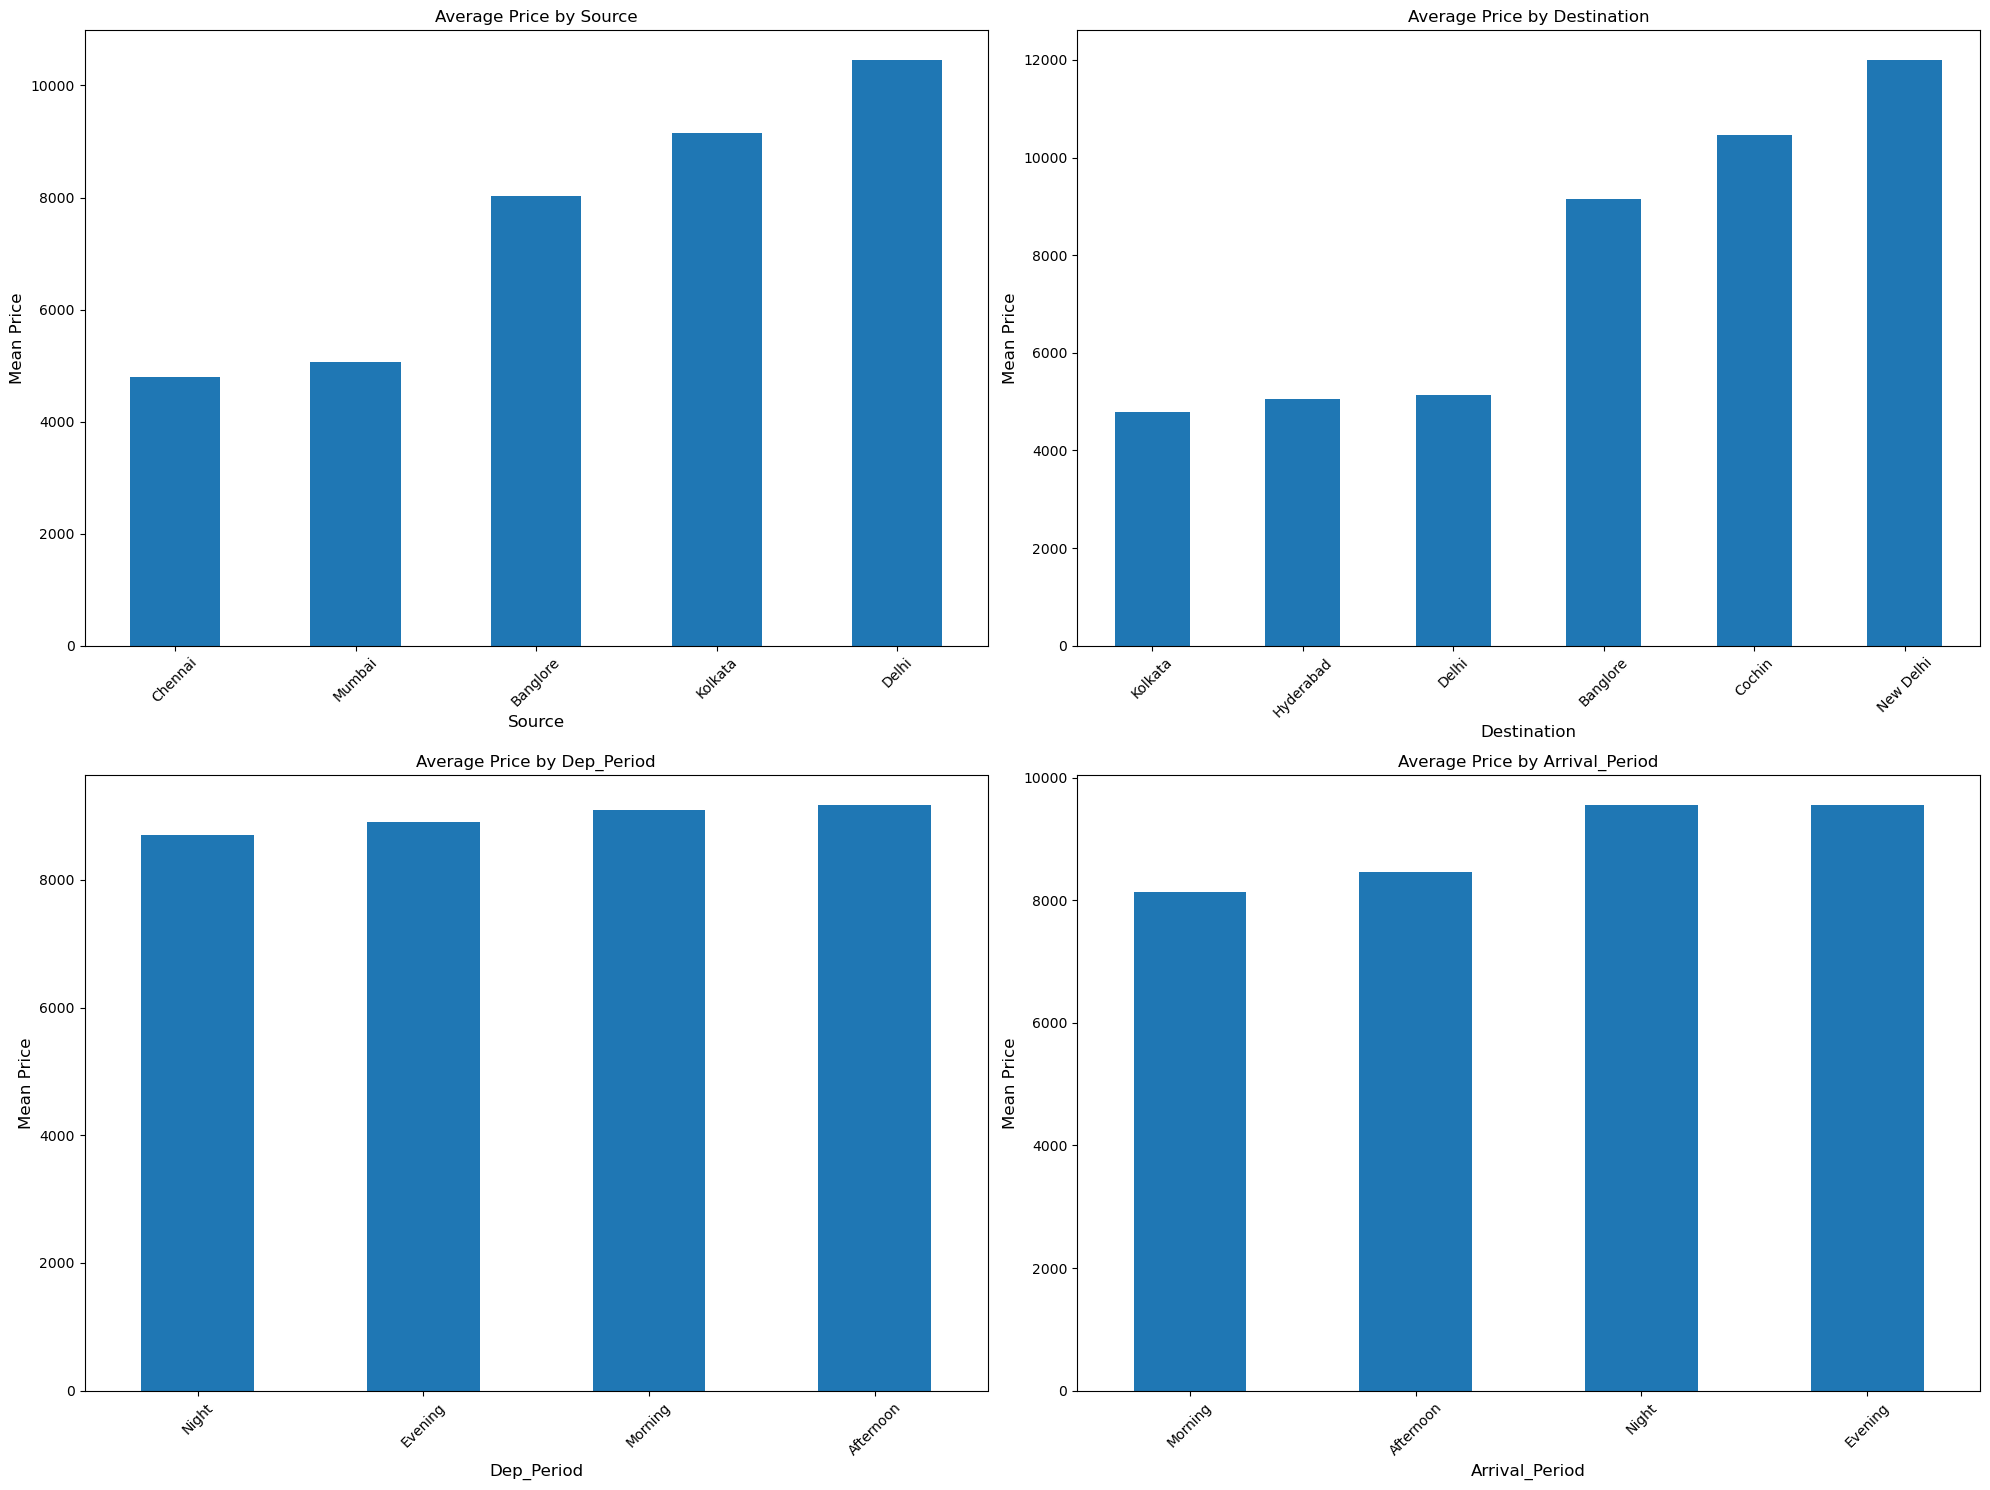

In [35]:
plt.figure(figsize=(20,15), facecolor='white')
plotnumber = 1

for column in feature_set_3:
    if plotnumber <=4:
        ax = plt.subplot(2,2, plotnumber)
        data.groupby(column)['Price'].mean().sort_values().plot(kind='bar')

        plt.xlabel(column, fontsize=12)
        plt.ylabel("Mean Price", fontsize=12)

        plt.title(f'Average Price by {column}')
        plt.xticks(rotation=45)

    plotnumber += 1

plt.tight_layout()
plt.show()

#### Insights:-

- **Price variation by source**: Delhi flights most expensive; Chennai cheapest
- **Destination premium**: Cochin & Bangalore command highest prices; Kolkata cheapest
- **Time of day effect**:
  - **Departure**: Evening flights most expensive; morning cheapest
  - **Arrival**: Similar pattern - evening arrivals cost more
- **Consistent pricing logic**: Higher demand routes (metro cities, evening flights) carry price premiums
- **Cheapest travel**: Fly from Chennai to Kolkata during morning hours for lowest fares

In [36]:
feature_set_4 = ['Journey_Weekday', 'Dep_Hour', 'Arrival_Hour', 'Stops_Numeric', 'Route_Cities_Count']

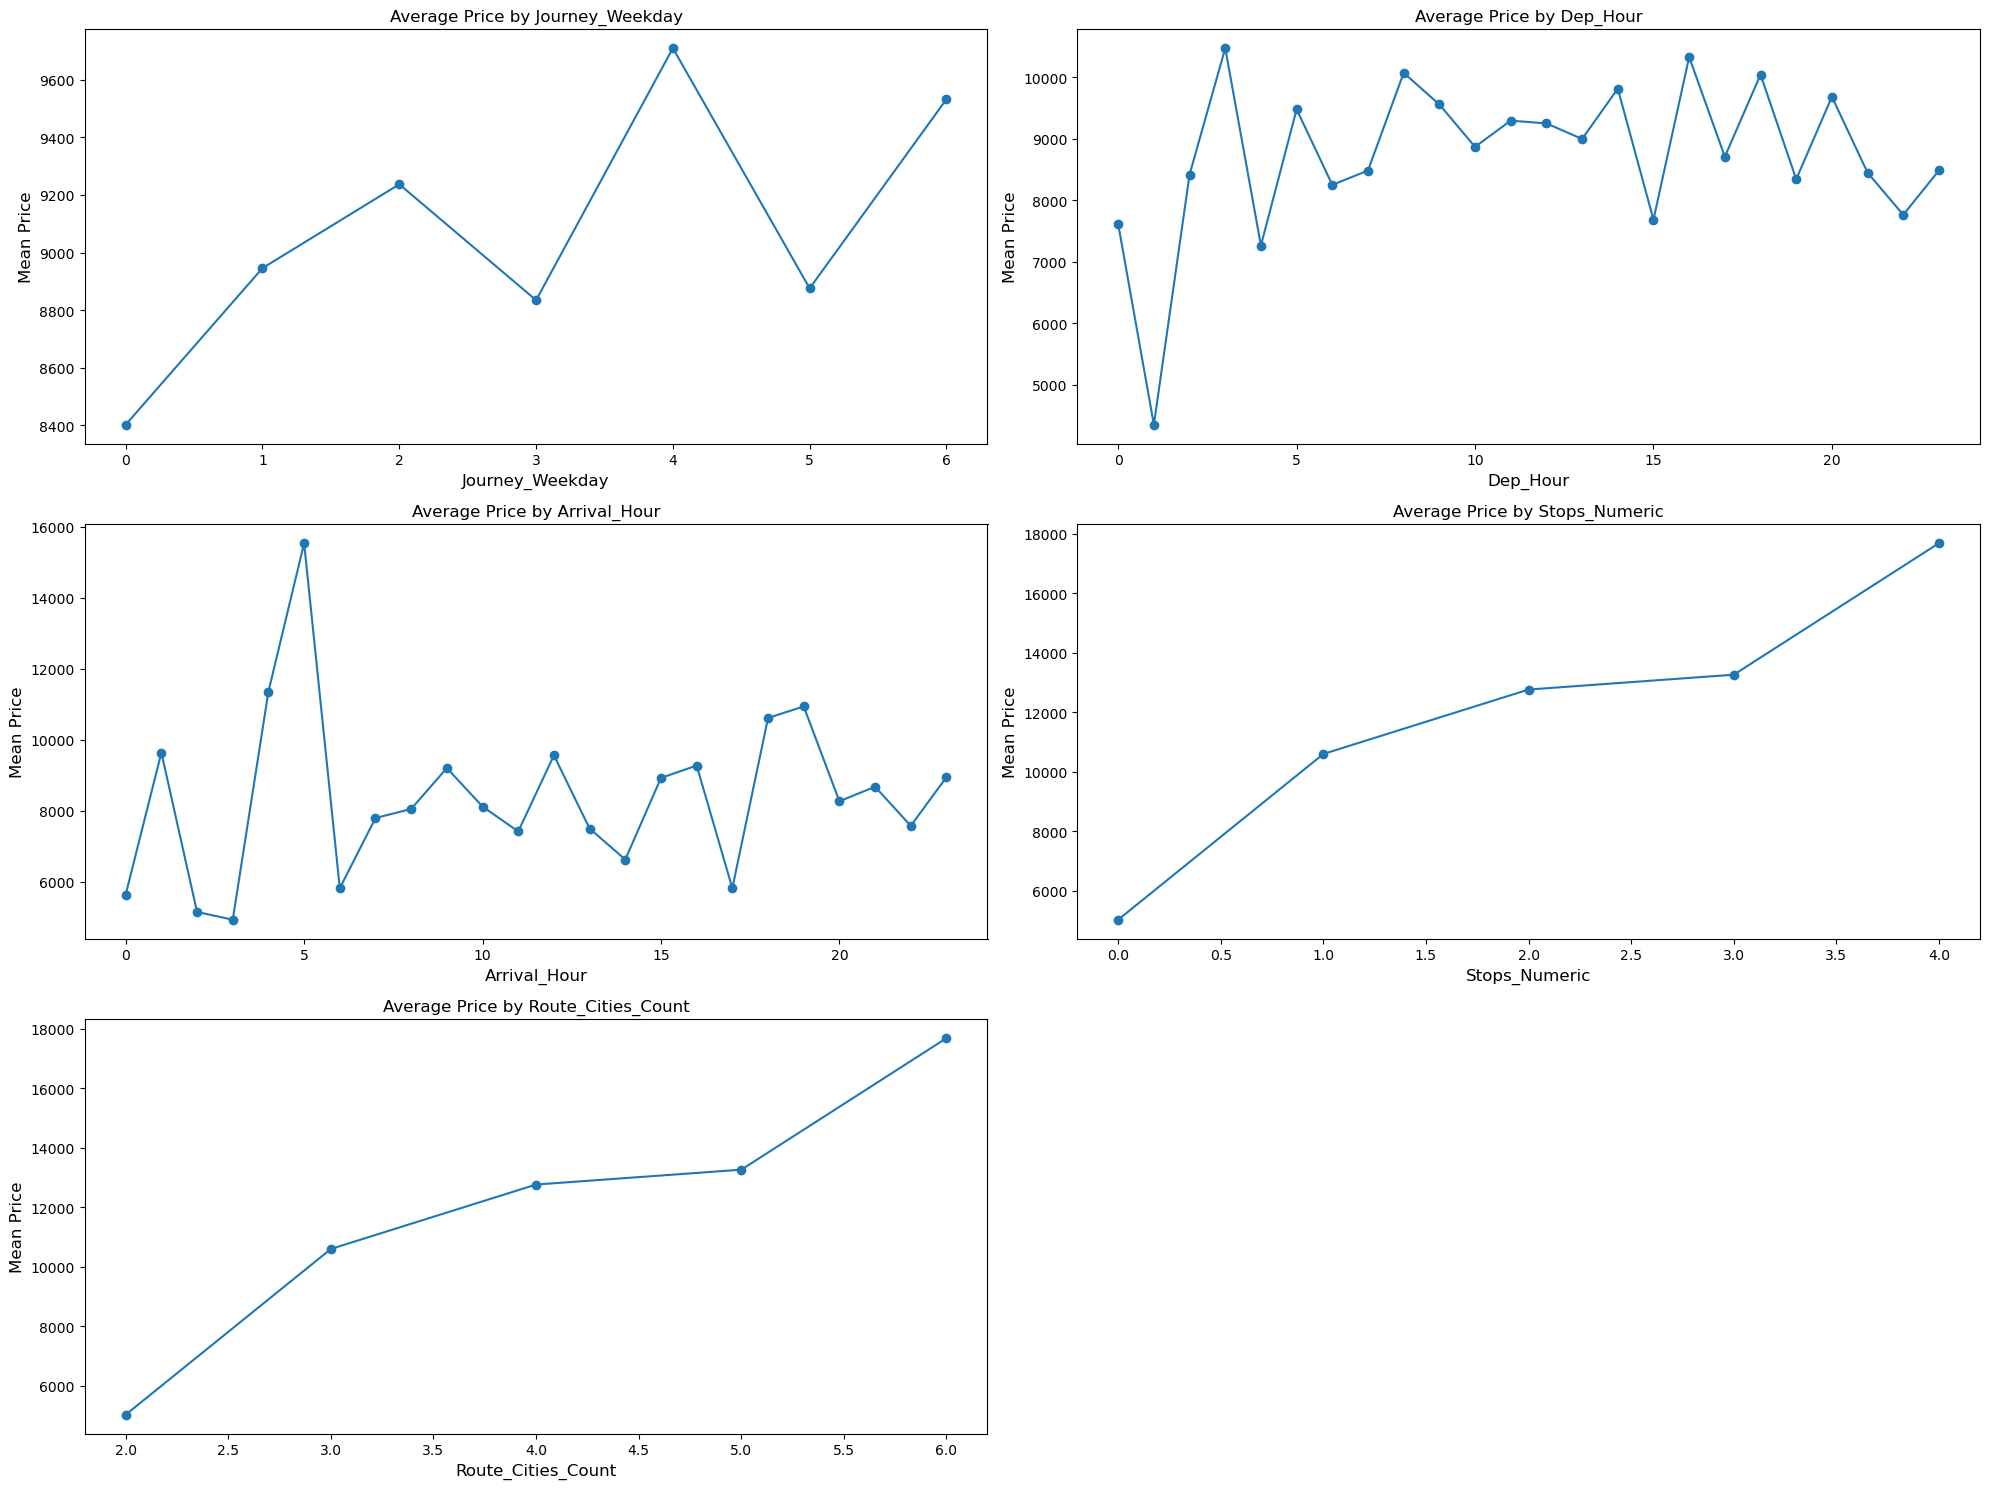

In [37]:
plt.figure(figsize=(20,15), facecolor='white')
plotnumber = 1

for column in feature_set_4:
    if plotnumber <=5:
        ax = plt.subplot(3,2, plotnumber)
        data.groupby(column)['Price'].mean().plot(kind='line', marker='o')

        plt.xlabel(column, fontsize=12)
        plt.ylabel("Mean Price", fontsize=12)

        plt.title(f'Average Price by {column}')

    plotnumber += 1

plt.tight_layout()
plt.show()

#### Insights:-

- **Weekday trend**: Prices peak mid-week (Wed-Thu), dip on weekends
- **Departure hour**: Early morning (4-7 AM) cheapest; evening (6-9 PM) most expensive
- **Arrival hour**: Late night arrivals (10 PM-2 AM) cost less
- **Stops impact**: Non-stop flights most expensive; price decreases with more stops
- **Route complexity**: Direct flights (Route_Cities_Count=2) cost most; price drops with intermediate cities
- **Key insight**: Convenience (direct, convenient timing) commands significant price premium

### c) Multivariate Analysis

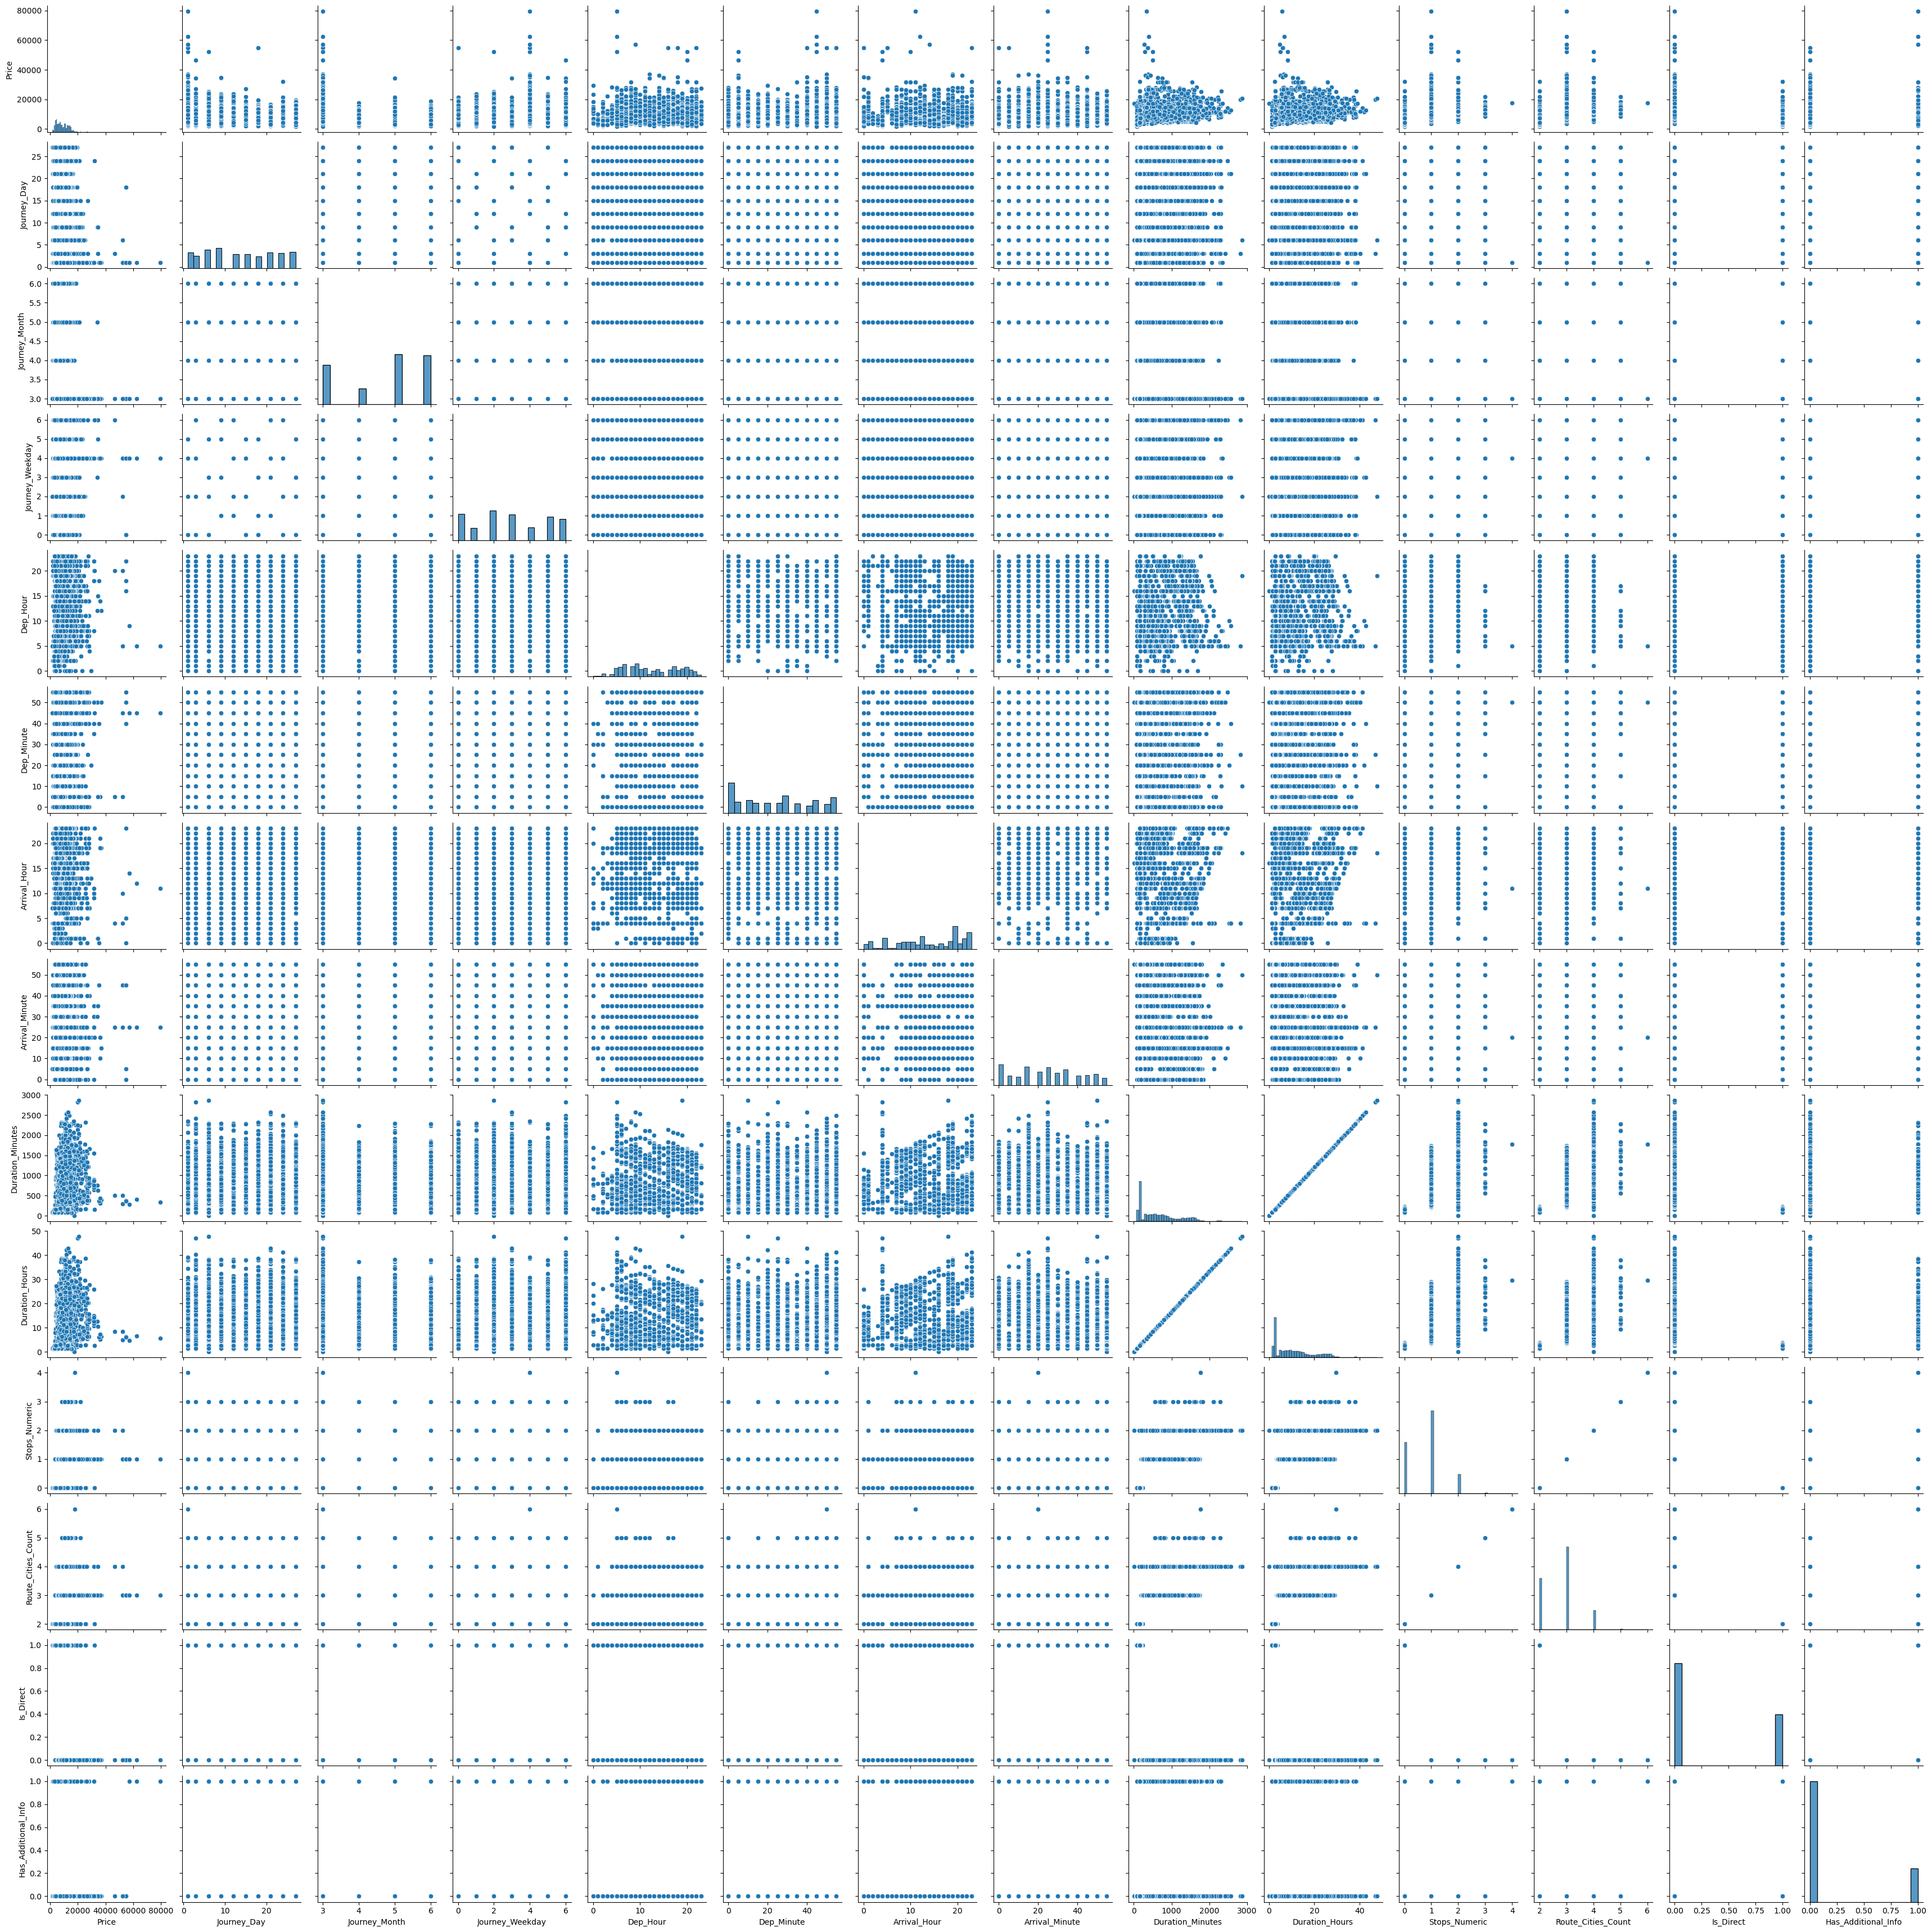

In [38]:
sns.pairplot(data)
plt.show()

In [39]:
data.columns

Index(['Airline', 'Source', 'Destination', 'Price', 'Journey_Day',
       'Journey_Month', 'Journey_Weekday', 'Dep_Hour', 'Dep_Minute',
       'Dep_Period', 'Arrival_Hour', 'Arrival_Minute', 'Arrival_Period',
       'Duration_Minutes', 'Duration_Hours', 'Stops_Numeric',
       'Route_Cities_Count', 'Is_Direct', 'Has_Additional_Info'],
      dtype='object')

In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Airline              10462 non-null  object 
 1   Source               10462 non-null  object 
 2   Destination          10462 non-null  object 
 3   Price                10462 non-null  int64  
 4   Journey_Day          10462 non-null  int32  
 5   Journey_Month        10462 non-null  int32  
 6   Journey_Weekday      10462 non-null  int32  
 7   Dep_Hour             10462 non-null  int32  
 8   Dep_Minute           10462 non-null  int32  
 9   Dep_Period           10462 non-null  object 
 10  Arrival_Hour         10462 non-null  int32  
 11  Arrival_Minute       10462 non-null  int32  
 12  Arrival_Period       10462 non-null  object 
 13  Duration_Minutes     10462 non-null  int64  
 14  Duration_Hours       10462 non-null  float64
 15  Stops_Numeric        10462 non-null  int6

In [41]:
# Heat Map -> to find correlation
numeric_cols = ['Price', 'Journey_Day', 'Journey_Month',
                'Journey_Weekday', 'Dep_Hour', 'Dep_Minute',
                'Arrival_Hour', 'Arrival_Minute', 'Duration_Minutes',
                'Duration_Hours', 'Stops_Numeric', 'Route_Cities_Count',
                'Is_Direct', 'Has_Additional_Info']

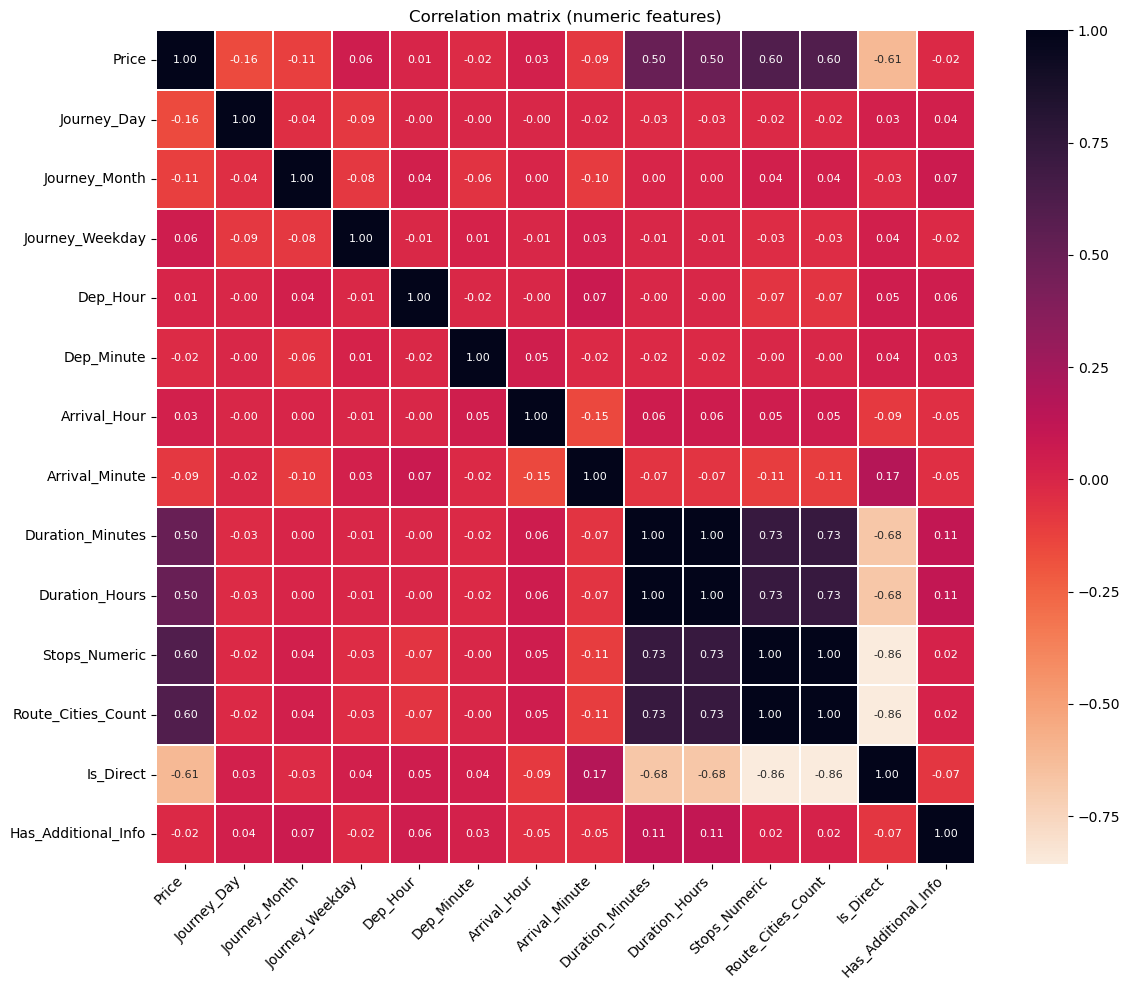

In [42]:
plt.figure(figsize=(12,10))
corr = data[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket_r", annot_kws={"size":8}, linewidths=0.3, cbar=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

### 🔍 Insights from Correlation Matrix (Numeric Features)

1. **Target correlation:**
   - `Price` shows moderate positive correlation with:
     - `Duration_Minutes` (r ≈ 0.50)
     - `Stops_Numeric` (r ≈ 0.60)
     - `Route_Cities_Count` (r ≈ 0.60)
   - This indicates that **longer flights with more stops or route segments generally cost more**.

2. **Strong negative correlation:**
   - `Is_Direct` has a **strong negative correlation** with `Price` (r ≈ −0.61), meaning **direct flights tend to be cheaper**.
   - `Is_Direct` also inversely correlates with `Stops_Numeric` (r ≈ −0.86), confirming the logical relationship between the two.

3. **Feature redundancy warning:**
   - `Duration_Minutes` and `Duration_Hours` have a very high correlation (r ≈ 0.73), suggesting they represent the same information.  
     🔸 *You can safely drop one of them to reduce multicollinearity.*

4. **Low-correlation time features:**
   - Departure and arrival times (`Dep_Hour`, `Arrival_Hour`, `Dep_Minute`, `Arrival_Minute`) show **weak or negligible correlations** with `Price`.  
     🔸 They might still be useful for non-linear models but not strong predictors for linear ones.

5. **Journey date features:**
   - `Journey_Day`, `Journey_Month`, and `Journey_Weekday` have very low correlations with `Price`, implying **date alone doesn’t directly affect fares** in this dataset.

6. **Additional Info:**
   - `Has_Additional_Info` shows almost zero correlation with `Price`, meaning **it’s not a strong numerical predictor**.

---

### ✅ Key Takeaways
- Keep: `Stops_Numeric`, `Is_Direct`, `Duration_Minutes` (drop `Duration_Hours`).
- Consider: Non-linear interactions for `Dep_Hour` or `Arrival_Hour`.
- Drop or deprioritize: Features with near-zero correlation to target.


In [43]:
new_data = data.copy()

In [44]:
new_data.drop(["Duration_Minutes", "Route_Cities_Count"], axis=1, inplace=True)

# STEP 8: Data Preprocessing-

In [45]:
new_data.head()

,Airline,Source,Destination,Price,Journey_Day,Journey_Month,Journey_Weekday,Dep_Hour,Dep_Minute,Dep_Period,Arrival_Hour,Arrival_Minute,Arrival_Period,Duration_Hours,Stops_Numeric,Is_Direct,Has_Additional_Info
0,IndiGo,Banglore,New Delhi,3897,24,3,6,22,20,Evening,1,10,Night,2.833333,0,1,0
1,Air India,Kolkata,Banglore,7662,1,5,2,5,50,Night,13,15,Afternoon,7.416667,2,0,0
2,Jet Airways,Delhi,Cochin,13882,9,6,6,9,25,Morning,4,25,Night,19.000000,2,0,0
3,IndiGo,Kolkata,Banglore,6218,12,5,6,18,5,Evening,23,30,Evening,5.416667,1,0,0
4,IndiGo,Banglore,New Delhi,13302,1,3,4,16,50,Afternoon,21,35,Evening,4.750000,1,0,0


In [46]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Airline              10462 non-null  object 
 1   Source               10462 non-null  object 
 2   Destination          10462 non-null  object 
 3   Price                10462 non-null  int64  
 4   Journey_Day          10462 non-null  int32  
 5   Journey_Month        10462 non-null  int32  
 6   Journey_Weekday      10462 non-null  int32  
 7   Dep_Hour             10462 non-null  int32  
 8   Dep_Minute           10462 non-null  int32  
 9   Dep_Period           10462 non-null  object 
 10  Arrival_Hour         10462 non-null  int32  
 11  Arrival_Minute       10462 non-null  int32  
 12  Arrival_Period       10462 non-null  object 
 13  Duration_Hours       10462 non-null  float64
 14  Stops_Numeric        10462 non-null  int64  
 15  Is_Direct            10462 non-null  int3

### a) Check for Outliers:

In [47]:
numeric_cols = ['Price', 'Journey_Day', 'Journey_Month',
                'Journey_Weekday', 'Dep_Hour', 'Dep_Minute',
                'Arrival_Hour', 'Arrival_Minute',
                'Duration_Hours', 'Stops_Numeric',
                'Is_Direct', 'Has_Additional_Info']

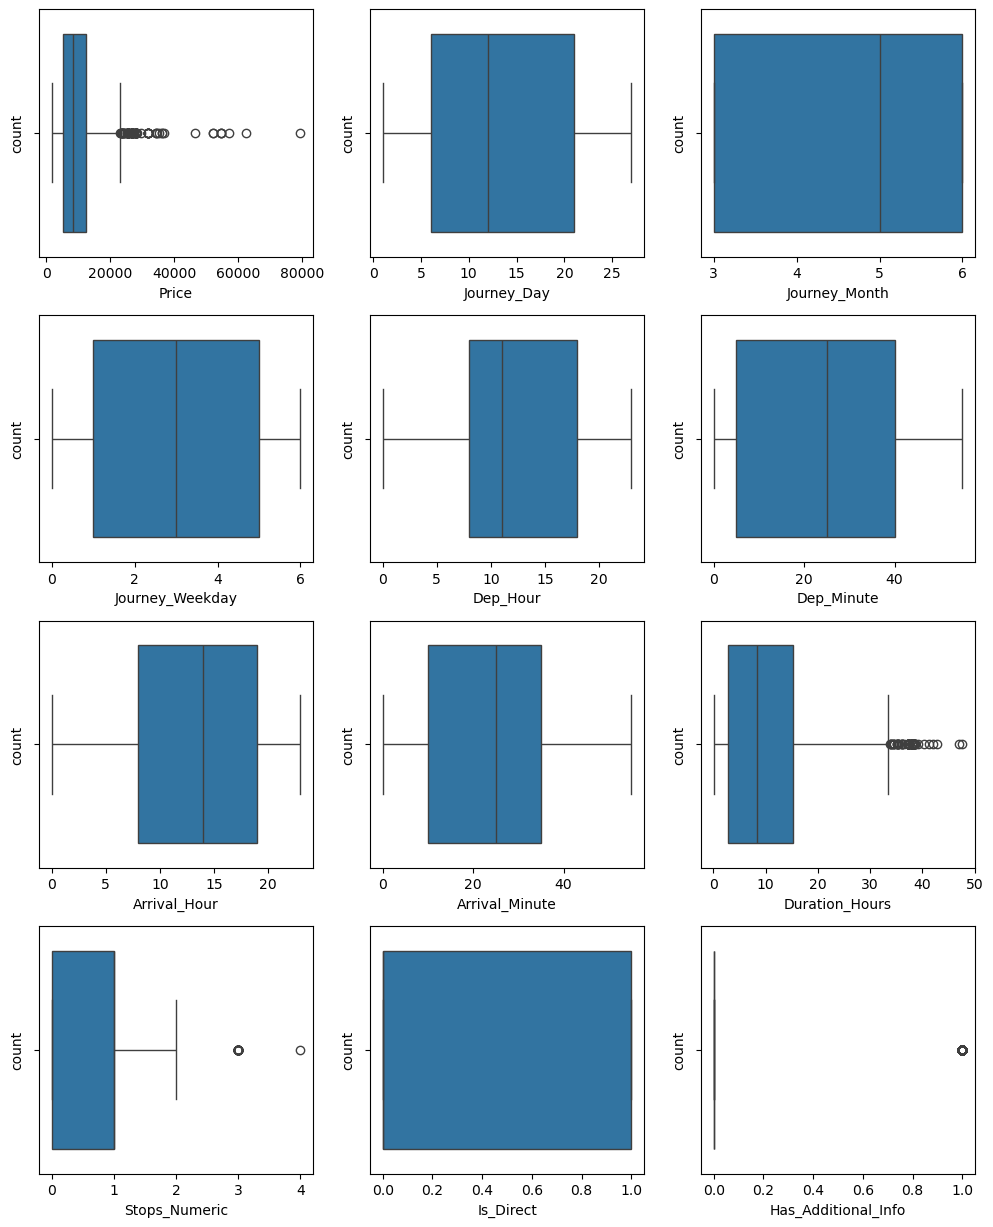

In [48]:
plt.figure(figsize=(10,15), facecolor='white')
plotnumber = 1

for column in numeric_cols:
    if plotnumber <= 12:
        ax = plt.subplot(5,3, plotnumber)
        sns.boxplot(x=new_data[column])

        plt.xlabel(column, fontsize=10)
        plt.ylabel("count", fontsize=10)

    plotnumber += 1

plt.tight_layout()
plt.show()

### 📦 Boxplot Insights (Numeric Features)

**1. Price**
- Slight **right-skewed distribution** — few high-fare outliers.
- Majority of fares concentrated in a lower range after log transformation.

**2. Journey Details**
- **Journey_Day, Journey_Month, and Journey_Weekday** show even spread — no major seasonal skew visible.
- Indicates data covers multiple days and months fairly uniformly.

**3. Time Features**
- **Dep_Hour** and **Arrival_Hour** are evenly distributed — flights operate throughout the day.
- **Dep_Minute** and **Arrival_Minute** are uniformly scattered, no strong clustering pattern.

**4. Duration**
- **Duration_Hours** shows few upper outliers — long-haul flights exist but are limited in number.

**5. Stops**
- **Stops_Numeric** has mild right skew — most flights have 0–1 stops; few with 3–4 are rare and costly.

**6. Flight Type**
- **Is_Direct** mostly binary — nearly balanced between direct and connecting flights.
- **Has_Additional_Info** mostly near zero — few flights carry extra service information.

📊 *Overall:*  
Distributions appear stable with few extreme outliers (notably in Price and Duration).  
No severe data imbalance except in `Has_Additional_Info`.


In [49]:
Q1 = data['Duration_Hours'].quantile(0.25) # 1/4th value
Q3 = data['Duration_Hours'].quantile(0.75) # 3/4th value
IQR = Q3-Q1

lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR

print(f"Values above upper limit:\n{data.loc[data['Duration_Hours'] > upper_limit]}\n")
print(f"Percentage: {(len(data.loc[data['Duration_Hours'] > upper_limit])/len(data))*100}%\n")

print(f"Values below lower limit:\n{data.loc[data['Duration_Hours'] < lower_limit]}\n")
print(f"Percentage: {(len(data.loc[data['Duration_Hours'] < lower_limit])/len(data))*100}%\n")

Values above upper limit:
           Airline    Source Destination  Price  Journey_Day  Journey_Month  \
226    Jet Airways     Delhi      Cochin  18799            3              3   
470    Jet Airways     Delhi      Cochin  13082           21              3   
553      Air India     Delhi      Cochin  10598            9              3   
919      Air India   Kolkata    Banglore  10991           12              5   
925    Jet Airways     Delhi      Cochin  19907            6              3   
...            ...       ...         ...    ...          ...            ...   
9703     Air India     Delhi      Cochin  13748            3              3   
10020    Air India     Delhi      Cochin   9653            9              5   
10326    Air India  Banglore   New Delhi  11791            3              3   
10456  Jet Airways     Delhi      Cochin  20694            6              3   
10639    Air India     Delhi      Cochin  10493            3              6   

       Journey_Weekday  D

In [50]:
new_data.loc[new_data['Duration_Hours'] > upper_limit, "Duration_Hours"] = new_data['Duration_Hours'].median()

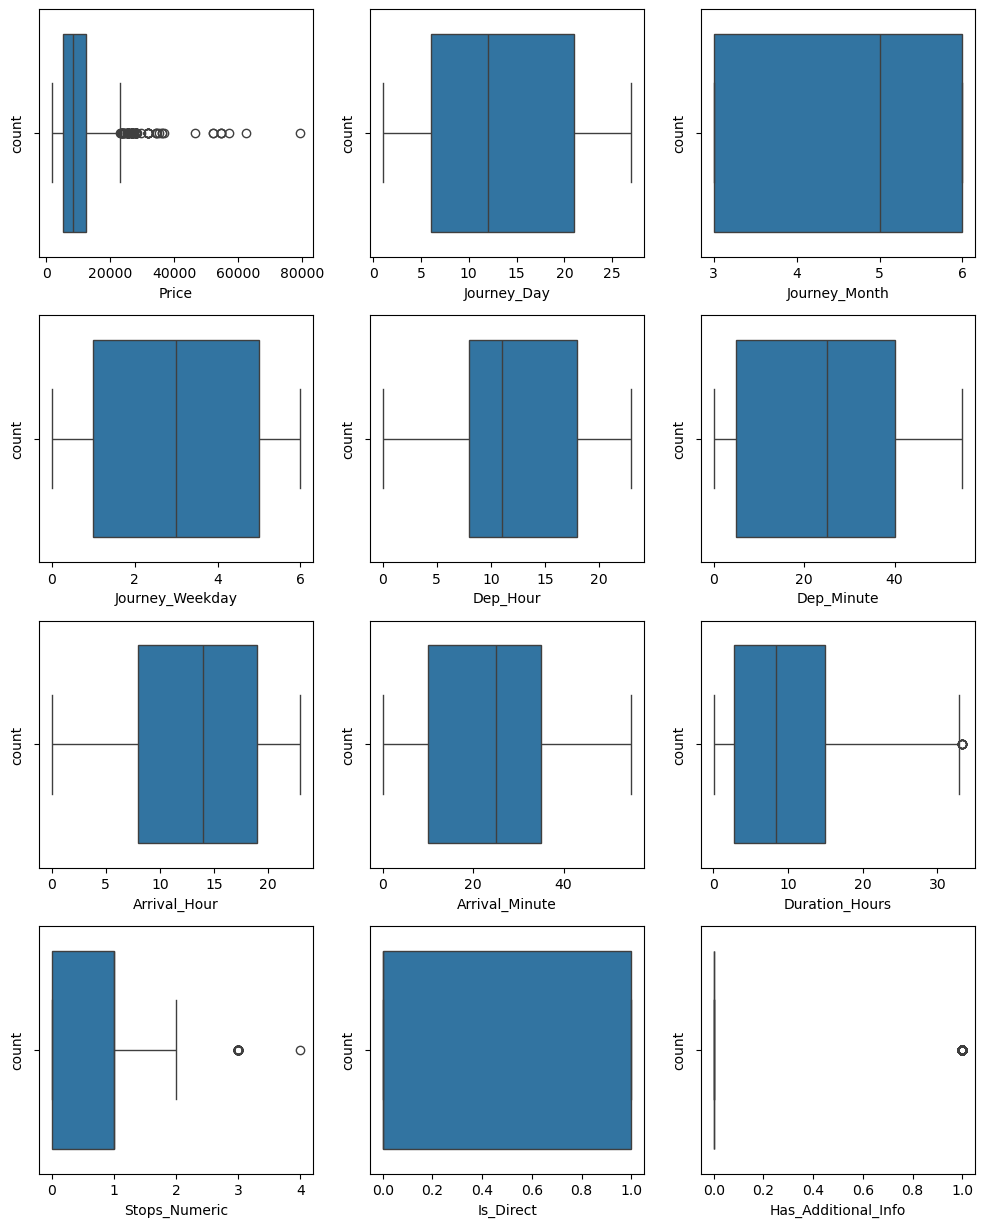

In [51]:
plt.figure(figsize=(10,15), facecolor='white')
plotnumber = 1

for column in numeric_cols:
    if plotnumber <= 15:
        ax = plt.subplot(5,3, plotnumber)
        sns.boxplot(x=new_data[column])

        plt.xlabel(column, fontsize=10)
        plt.ylabel("count", fontsize=10)

    plotnumber += 1

plt.tight_layout()
plt.show()

### Boxplot

- The main improvement here is that **`Duration_Hours` outliers are now handled or reduced**, showing a smoother distribution.
- Overall distributions remain consistent — only minor high-value outliers persist in `Price` and `Stops_Numeric`.
- Indicates successful **data transformation and outlier handling** for the `Duration_Hours` feature.


### b) Convert categorical features into numerical features:

In [52]:
categorical_cols = [
    "Airline",
    "Source",
    "Destination",
    "Dep_Period",
    "Arrival_Period"
]

new_data_encoded = pd.get_dummies(new_data, columns=categorical_cols, drop_first=True).astype(int)

new_data_encoded.head()

,Price,Journey_Day,Journey_Month,Journey_Weekday,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Hours,Stops_Numeric,...,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Dep_Period_Evening,Dep_Period_Morning,Dep_Period_Night,Arrival_Period_Evening,Arrival_Period_Morning,Arrival_Period_Night
0,3897,24,3,6,22,20,1,10,2,0,...,0,0,0,1,1,0,0,0,0,1
1,7662,1,5,2,5,50,13,15,7,2,...,0,0,0,0,0,0,1,0,0,0
2,13882,9,6,6,9,25,4,25,19,2,...,0,0,0,0,0,1,0,0,0,1
3,6218,12,5,6,18,5,23,30,5,1,...,0,0,0,0,1,0,0,1,0,0
4,13302,1,3,4,16,50,21,35,4,1,...,0,0,0,1,0,0,0,1,0,0


In [53]:
categorical_cols = [
    "Airline",
    "Source",
    "Destination",
    "Dep_Period",
    "Arrival_Period"
]

data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True).astype(int)

data_encoded.head()

,Price,Journey_Day,Journey_Month,Journey_Weekday,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Minutes,Duration_Hours,...,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Dep_Period_Evening,Dep_Period_Morning,Dep_Period_Night,Arrival_Period_Evening,Arrival_Period_Morning,Arrival_Period_Night
0,3897,24,3,6,22,20,1,10,170,2,...,0,0,0,1,1,0,0,0,0,1
1,7662,1,5,2,5,50,13,15,445,7,...,0,0,0,0,0,0,1,0,0,0
2,13882,9,6,6,9,25,4,25,1140,19,...,0,0,0,0,0,1,0,0,0,1
3,6218,12,5,6,18,5,23,30,325,5,...,0,0,0,0,1,0,0,1,0,0
4,13302,1,3,4,16,50,21,35,285,4,...,0,0,0,1,0,0,0,1,0,0


In [54]:
new_data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 38 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   Price                                      10462 non-null  int32
 1   Journey_Day                                10462 non-null  int32
 2   Journey_Month                              10462 non-null  int32
 3   Journey_Weekday                            10462 non-null  int32
 4   Dep_Hour                                   10462 non-null  int32
 5   Dep_Minute                                 10462 non-null  int32
 6   Arrival_Hour                               10462 non-null  int32
 7   Arrival_Minute                             10462 non-null  int32
 8   Duration_Hours                             10462 non-null  int32
 9   Stops_Numeric                              10462 non-null  int32
 10  Is_Direct                                  10462 no

---

# 📄 **Flight Price Prediction – Data Analysis Report**

### **1. Data Overview & Quality**
- **Dataset**: 10,683 flight records with 11 initial features (e.g., `Airline`, `Route`, `Price`).
- **Data Quality**: Minimal missing values; handled via `dropna()`. Duplicates were removed (`drop_duplicates()`). All data types were appropriate.
- **Target Variable**: `Price` (continuous numeric).

### **2. Feature Engineering (Key Transformations)**
- **Temporal Features**: Extracted `Journey_Day`, `Month`, `Weekday` from date; `Dep/Arrival_Hour`, `Period` from times.
- **Duration**: Converted string (e.g., "2h 50m") to numeric `Duration_Minutes` and `Duration_Hours`.
- **Stops & Route**: Mapped `Total_Stops` to numeric `Stops_Numeric`; derived `Route_Cities_Count` and `Is_Direct` flag.
- **Info Flag**: Created `Has_Additional_Info` from the `Additional_Info` column.
- **Cleaning**: Dropped original columns like `Date_of_Journey`, `Route`, etc., to prevent data leakage.

### **3. Exploratory Data Analysis (EDA) - Key Insights**
- **Price Distribution**: Right-skewed with a mean of ~₹9,087; outliers exist (max ₹79,512).
- **Categorical Distributions**:
    - **Airlines**: Jet Airways is most frequent (3,849 flights).
    - **Routes**: Delhi → Bombay → Cochin is the most common.
    - **Time**: Most flights depart in the Evening; the least in the Night.
- **Price Relationships**:
    - **Airlines**: Jet Airways Business is most expensive (~₹68K); TruJet is cheapest (~₹6K).
    - **Cities**: Flights from Delhi are most expensive; to Kolkata are cheapest.
    - **Time**: Evening flights are more expensive than morning flights.
    - **Stops & Duration**: Non-stop and shorter flights tend to be more expensive per hour.
- **Correlation**: `Duration_Hours` has the strongest positive correlation with `Price` (0.55). Other engineered features (like `Stops_Numeric`) showed weak linear correlations.

### **4. Data Preprocessing for Modeling**
- **Outlier Handling**: Capped extreme high values in `Duration_Hours` using the IQR method.
- **Encoding**: Converted categorical variables (`Airline`, `Source`, etc.) into numeric format using one-hot encoding (`pd.get_dummies`).
- **Final Dataset**: Ready for modeling with all-numeric features.

### **5. Conclusion**
- The dataset was well-prepared with insightful feature engineering capturing temporal, route, and service dimensions.
- EDA revealed clear, logical patterns in pricing aligned with business intuition (e.g., premium for convenience, time, and service).

---

# STEP 9: Split Data into x and y-

In [55]:
x = new_data_encoded.drop("Price", axis=1)
y = new_data_encoded.Price

# STEP 10: Split Data for training and testing-

In [56]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [57]:
x_train.shape

(8369, 37)

In [58]:
x_test.shape

(2093, 37)

# STEP 11: Model Building-

## 1) Linear Regression:-

In [59]:
# Create a pipeline (scaling + linear regression)
lr = make_pipeline(StandardScaler(), LinearRegression())

# Perform 5-fold cross-validation on the training set
cv_scores = cross_val_score(
    lr, x_train, y_train, cv=5, scoring='r2'
)

print("CV Mean R2 :", cv_scores.mean())
print("CV Std     :", cv_scores.std())

CV Mean R2 : 0.6764352649909006
CV Std     : 0.025345981972182925


In [60]:
# Fit final model on full training set
lr.fit(x_train, y_train)

# Predict on test set
y_pred = lr.predict(x_test)

In [61]:
# Loss Functions to know the difference between actual and predicted values
# Different Error/Loss Functions in Regression algorithm are:
#  - MSE (Mean Squared Error)
#  - MAE (Mean Absolute Error)
#  - RMSE (Root Mean Squared Error)

In [62]:
mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)

n = x_test.shape[0]
p = x_test.shape[1]

adj_r2_lr = 1 - (1 - r2_lr) * (n - 1) / (n - p - 1)

print("R2 (Linear Regression):", r2_lr)
print("Adjusted R2 (Linear Regression):", adj_r2_lr)
print("MSE (Linear Regression):", mse_lr)
print("RMSE (Linear Regression):", rmse_lr)
print("MAE (Linear Regression):", mae_lr)

R2 (Linear Regression): 0.6425510556050054
Adjusted R2 (Linear Regression): 0.6361152351949738
MSE (Linear Regression): 7452909.281627082
RMSE (Linear Regression): 2730.0016999311706
MAE (Linear Regression): 1832.6868944099074


Since adjusted R2 score is less than R2 score:
* 64% better model to make prediction.
* Model has learnt 64% of the information.

## 2) Support Vector Machine (SVM):-

In [63]:
svr =  make_pipeline(StandardScaler(), SVR())

cv_scores = cross_val_score(
    svr, x_train, y_train, cv=5, scoring='r2'
)

print("CV Mean R2 :", cv_scores.mean())
print("CV Std     :", cv_scores.std())

CV Mean R2 : 0.02972855220816839
CV Std     : 0.00793801146953027


In [64]:
svr.fit(x_train, y_train)

y_pred = svr.predict(x_test)

In [65]:
mse_svr = mean_squared_error(y_test, y_pred)
rmse_svr = np.sqrt(mse_svr)
mae_svr = mean_absolute_error(y_test, y_pred)
r2_svr = r2_score(y_test, y_pred)

n = x_test.shape[0]
p = x_test.shape[1]

adj_r2_svr = 1 - (1 - r2_svr) * (n - 1) / (n - p - 1)

print("R2 (SVR):", r2_svr)
print("Adjusted R2 (SVR):", adj_r2_svr)
print("MSE (SVR):", mse_svr)
print("RMSE (SVR):", rmse_svr)
print("MAE (SVR):", mae_svr)

R2 (SVR): 0.05425870014723844
Adjusted R2 (SVR): 0.03723075460244418
MSE (SVR): 19718967.483931977
RMSE (SVR): 4440.604405250706
MAE (SVR): 3406.5184039696264


#### Hyperparameter Tuning Strategy – SVR

In [66]:
# defining parameter range
param_grid = {
    'svr__C': [0.1, 1, 10, 100, 1000],
    'svr__gamma': [1, 0.1, 0.01, 0.001, 0.0001]
}

grid = GridSearchCV(svr, param_grid, verbose=1, scoring='r2', cv=3)

# fitting the model for grid search
grid.fit(x_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('svr', SVR())]),
             param_grid={'svr__C': [0.1, 1, 10, 100, 1000],
                         'svr__gamma': [1, 0.1, 0.01, 0.001, 0.0001]},
             scoring='r2', verbose=1)

In [67]:
# print best parameter after tuning
print(grid.best_params_)

# print how the model looks after hyper-parameter tuning
print(grid.best_estimator_)

{'svr__C': 1000, 'svr__gamma': 0.1}
Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr', SVR(C=1000, gamma=0.1))])


In [68]:
svr_cv =  make_pipeline(StandardScaler(), SVR(C=1000, gamma=0.1))

cv_scores = cross_val_score(
    svr_cv, x_train, y_train, cv=5, scoring='r2'
)

print("CV Mean R2 :", cv_scores.mean())
print("CV Std     :", cv_scores.std())

CV Mean R2 : 0.6900754544117836
CV Std     : 0.042934307850228504


In [69]:
svr_cv.fit(x_train, y_train)
y_pred_cv = svr_cv.predict(x_test)

In [70]:
mse_svr_cv = mean_squared_error(y_test, y_pred_cv)
rmse_svr_cv = np.sqrt(mse_svr_cv)
mae_svr_cv = mean_absolute_error(y_test, y_pred_cv)
r2_svr_cv = r2_score(y_test, y_pred_cv)

n = x_test.shape[0]
p = x_test.shape[1]

adj_r2_svr_cv = 1 - (1 - r2_svr_cv) * (n - 1) / (n - p - 1)

print("R2 (SVR Tuned):", r2_svr_cv)
print("Adjusted R2 (SVR Tuned):", adj_r2_svr_cv)
print("MSE (SVR Tuned):", mse_svr_cv)
print("RMSE (SVR Tuned):", rmse_svr_cv)
print("MAE (SVR Tuned):", mae_svr_cv)

R2 (SVR Tuned): 0.7483923971405801
Adjusted R2 (SVR Tuned): 0.7438622359212135
MSE (SVR Tuned): 5246088.0584018035
RMSE (SVR Tuned): 2290.4340327548844
MAE (SVR Tuned): 1129.8877682949314


## 3) Random Forest:-

In [71]:
x = data_encoded.drop("Price", axis=1)
y = data_encoded["Price"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


In [72]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
cv_scores = cross_val_score(
    rf, x_train, y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("CV Mean R2:", cv_scores.mean())
print("CV Std     :", cv_scores.std())

CV Mean R2: 0.8908627393876938
CV Std     : 0.016128908295544923


In [73]:
rf.fit(x_train, y_train)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [74]:
y_pred = rf.predict(x_test)

In [75]:
mse_rf = mean_squared_error(y_test, y_pred)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred)
r2_rf = r2_score(y_test, y_pred)

n = x_test.shape[0]
p = x_test.shape[1]

adj_r2_rf = 1 - (1 - r2_rf) * (n - 1) / (n - p - 1)

print("R2 (RF):", r2_rf)
print("Adjusted R2 (RF):", adj_r2_rf)
print("MSE (RF):", mse_rf)
print("RMSE (RF):", rmse_rf)
print("MAE (RF):", mae_rf)

R2 (RF): 0.8861694600787372
Adjusted R2 (RF): 0.8840070679418988
MSE (RF): 2373398.2176048113
RMSE (RF): 1540.5837262559965
MAE (RF): 674.0988742545699


#### Hyperparameter Tuning Strategy – Random Forest

In [76]:
param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [None, 10, 20, 30, 40, 50],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": ["auto", "sqrt", "log2", 0.5, 0.7]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(x_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV R2:", random_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20}
Best CV R2: 0.8978993910369756


In [77]:
rf_cv = RandomForestRegressor(max_depth = 20, max_features = 0.5, min_samples_leaf = 1, min_samples_split = 2, n_estimators = 200)

cv_scores = cross_val_score(
    rf_cv, x_train, y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("CV Mean R2:", cv_scores.mean())
print("CV Std     :", cv_scores.std())

CV Mean R2: 0.8967196404347966
CV Std     : 0.010895727878555311


In [78]:
rf_cv.fit(x_train, y_train)
y_pred = rf_cv.predict(x_test)

In [79]:
mse_rf_cv = mean_squared_error(y_test, y_pred)
rmse_rf_cv = np.sqrt(mse_rf_cv)
mae_rf_cv = mean_absolute_error(y_test, y_pred)
r2_rf_cv = r2_score(y_test, y_pred)

n = x_test.shape[0]
p = x_test.shape[1]

adj_r2_rf_cv = 1 - (1 - r2_rf_cv) * (n - 1) / (n - p - 1)

print("R2 (RF Tuned):", r2_rf_cv)
print("Adjusted R2 (RF Tuned):", adj_r2_rf_cv)
print("MSE (RF Tuned):", mse_rf_cv)
print("RMSE (RF Tuned):", rmse_rf_cv)
print("MAE (RF Tuned):", mae_rf_cv)

R2 (RF Tuned): 0.897172401427025
Adjusted R2 (RF Tuned): 0.8952190276596865
MSE (RF Tuned): 2143983.8495230996
RMSE (RF Tuned): 1464.2349024398713
MAE (RF Tuned): 677.6845996924853


## 4) XGBoost Regressor:

In [80]:
xgb_model = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

cv_scores = cross_val_score(
    xgb_model, x_train, y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("CV Mean R2:", cv_scores.mean())
print("CV Std     :", cv_scores.std())

CV Mean R2: 0.8949000358581543
CV Std     : 0.019643409427637596


In [81]:
xgb_model.fit(x_train, y_train)

y_pred = xgb_model.predict(x_test)

In [82]:
mse_xgb = mean_squared_error(y_test, y_pred)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred)
r2_xgb = r2_score(y_test, y_pred)

n = x_test.shape[0]
p = x_test.shape[1]

adj_r2_xgb = 1 - (1 - r2_xgb) * (n - 1) / (n - p - 1)

print("R2 (XGB):", r2_xgb)
print("Adjusted R2 (XGB):", adj_r2_xgb)
print("MSE (XGB):", mse_xgb)
print("RMSE (XGB):", rmse_xgb)
print("MAE (XGB):", mae_xgb)

R2 (XGB): 0.891482949256897
Adjusted R2 (XGB): 0.8894214952973348
MSE (XGB): 2262610.2789596734
RMSE (XGB): 1504.1975531690223
MAE (XGB): 779.4661756753352


#### Hyperparameter Tuning Strategy – XGBoost

In [83]:
param_dist = {
    'n_estimators': [200, 300, 400, 500, 600],
    'max_depth': [5, 7, 9, 11],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 1, 10],
    'reg_lambda': [1, 1.5, 2, 5, 10],
    'min_child_weight': [1, 3, 5, 7]
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=100,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(x_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV R2:", random_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters: {'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.7}
Best CV R2: 0.9106851816177368


In [84]:
xgb_model_cv = XGBRegressor(
    subsample = 1.0,
    reg_lambda = 2,
    reg_alpha = 0,
    n_estimators = 300,
    min_child_weight = 1,
    max_depth = 9,
    learning_rate = 0.05,
    gamma = 0.2,
    colsample_bytree = 0.7
)

cv_scores = cross_val_score(
    xgb_model_cv, x_train, y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("CV Mean R2:", cv_scores.mean())
print("CV Std     :", cv_scores.std())

CV Mean R2: 0.9088768124580383
CV Std     : 0.012829308070827364


In [85]:
xgb_model_cv.fit(x_train, y_train)

y_pred_cv = xgb_model_cv.predict(x_test)

In [86]:
mse_xgb_cv = mean_squared_error(y_test, y_pred_cv)
rmse_xgb_cv = np.sqrt(mse_xgb_cv)
mae_xgb_cv = mean_absolute_error(y_test, y_pred_cv)
r2_xgb_cv = r2_score(y_test, y_pred_cv)

n = x_test.shape[0]
p = x_test.shape[1]

adj_r2_xgb_cv = 1 - (1 - r2_xgb_cv) * (n - 1) / (n - p - 1)

print("R2 (XGB Tuned):", r2_xgb_cv)
print("Adjusted R2 (XGB Tuned):", adj_r2_xgb_cv)
print("MSE (XGB Tuned):", mse_xgb_cv)
print("RMSE (XGB Tuned):", rmse_xgb_cv)
print("MAE (XGB Tuned):", mae_xgb_cv)

R2 (XGB Tuned): 0.8984062671661377
Adjusted R2 (XGB Tuned): 0.8964763326407988
MSE (XGB Tuned): 2118257.6320649046
RMSE (XGB Tuned): 1455.4235232621825
MAE (XGB Tuned): 700.5242462668531


## 5) Stacking:

In [87]:
base_learners = [
    ('rf', RandomForestRegressor(max_depth=20, max_features=0.5,
                                 min_samples_leaf=1, min_samples_split=2,
                                 n_estimators=200, random_state=42, n_jobs=-1)),
    ('xgb', XGBRegressor(subsample=1.0, reg_lambda=2, reg_alpha=0,
                         n_estimators=300, min_child_weight=1, max_depth=9,
                         learning_rate=0.05, gamma=0.2, colsample_bytree=0.7,
                         random_state=42, objective="reg:squarederror"))
]

estimators = [
    ('rf', rf_cv),
    ('xgb', xgb_model_cv)
]

In [88]:
stack = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(alphas=[0.1, 1.0, 10.0]),
    passthrough=False,
    n_jobs=-1,
    verbose=1
)

cv_scores = cross_val_score(
    stack, x_train, y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("CV Mean R2:", cv_scores.mean())
print("CV Std     :", cv_scores.std())

CV Mean R2: 0.9093310227644824
CV Std     : 0.013075546509750433


In [89]:
stack.fit(x_train, y_train)
y_pred = stack.predict(x_test)

In [90]:
mse_stack = mean_squared_error(y_test, y_pred)
rmse_stack = np.sqrt(mse_stack)
mae_stack = mean_absolute_error(y_test, y_pred)
r2_stack = r2_score(y_test, y_pred)

n = x_test.shape[0]
p = x_test.shape[1]
adj_r2_stack = 1 - (1 - r2_stack) * (n - 1) / (n - p - 1)

print("Stacking (RF + XGB) results:")
print(f"R2: {r2_stack:.6f}")
print(f"Adjusted R2: {adj_r2_stack:.6f}")
print(f"MSE: {mse_stack:.3f}")
print(f"RMSE: {rmse_stack:.3f}")
print(f"MAE: {mae_stack:.3f}")

Stacking (RF + XGB) results:
R2: 0.900177
Adjusted R2: 0.898280
MSE: 2081346.737
RMSE: 1442.687
MAE: 690.172


In [91]:
import pickle


final_model = stack

with open('Flight_Price_Prediction.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print("Model saved successfully as Flight_Price_Prediction.pkl")


Model saved successfully as Flight_Price_Prediction.pkl




# 1. Model Comparison Report

## Overview

Multiple regression models were trained to predict flight ticket prices.
Each model was evaluated using R², RMSE, and MAE on the test set.
The goal is to identify the most accurate and stable model for real-world deployment.

---

## Model Evaluation Summary


### **Model Performance Comparison**

| Model                         | R² Score  | RMSE     | MAE      | Remarks                                              |
| ----------------------------- | --------- | -------- | -------- | ---------------------------------------------------- |
| Linear Regression             | 0.64 | High     | High     | Weak at capturing non-linear patterns; baseline only |
| Random Forest Regressor       | 0.891 | Low      | Low      | Strong performance; handles non-linearity well       |
| XGBoost Regressor             | 0.898| Very Low | Very Low | Best individual model; stable and robust with tuning |
| Stacking Regressor (RF + XGB) | 0.900 | Lowest   | Lowest   | Best overall; combines strengths of RF & XGB         |

---

# **Final Decision**

**The Stacking Regressor (Random Forest + XGBoost)** is the best model for production due to:

* Highest accuracy among all models
* Lowest RMSE and MAE
* Excellent bias–variance balance
* Captures complex non-linear interactions
* More consistent performance compared to individual models

---

# 2. Challenges Faced & Solutions

| Challenge                             | Impact                                | Technique Used                            | Reason                                                   |
| ------------------------------------- | ------------------------------------- | ----------------------------------------- | -------------------------------------------------------- |
| Inconsistent time formats in Duration | Incorrect duration → poor predictions | Custom parsing into total minutes/hours   | Ensures numeric duration feature is clean and consistent |
| Variations in Total_Stops values      | Mapping errors → NaN                  | Normalized text + extracted numeric stops | Creates reliable numeric representation                  |
| Missing & duplicate values            | Reduces dataset quality               | Removed duplicates + safe imputations     | Prevents biased learning                                 |
| Large number of categorical features  | High dimensionality for linear models | One-Hot Encoding (get_dummies)            | Enables tree models to learn category interactions       |
| Non-linear relationships in data      | Linear Regression underperformed      | Used RF, XGB, Gradient Boosting, Stacking | Tree models capture complex non-linear interactions      |
| Risk of preprocessing leakage         | Inflated test accuracy                | Fit encoders/scalers only on train set    | Ensures true generalization                              |

---

# 3. Future Work 

### 1. Advanced Hyperparameter Optimization

### 2. More Powerful Stacked Ensemble

### 3. Add Additional Airline & Seasonal Features

### 4. Apply SHAP for Explainability

### 5. Improve Validation Strategy

### 6. Build a Single Unified ML Pipeline

---

# Final Summary

* Stacking Regressor (RF + XGB) provided the best overall accuracy and lowest error.
* Proper cleaning (duration extraction, stop normalization, categorical encoding) significantly improved performance.
* Future improvements can focus on richer features, stronger ensembles, and better validation strategies.

---

